# Prediksi Customer Churn — E-Commerce Platform

by : Emir Abdallah

**Tautan deliverables:** [Tableau Dashboard](https://public.tableau.com/views/CustomerChurn--E-Commerce/Overview) · Streamlit App (menyusul) · [GitHub Repository](https://github.com/jcdspurwadhika/JCDSOHAM-07_Alpha)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)

## Business Understanding

### Background Context

Industri e-commerce global tumbuh dengan sangat pesat, dengan nilai pasar diperkirakan mencapai **$6,88 triliun pada tahun 2026** dan melibatkan lebih dari **2,86 miliar pembeli online** di seluruh dunia — merepresentasikan sekitar **21,1% dari total penjualan ritel global** ([eMarketer, 2026](https://www.companieshistory.com/e-commerce-market-statistics)). Di India secara khusus — konteks yang relevan dengan dataset ini — pertumbuhan e-commerce turut didorong oleh adopsi smartphone yang meningkat dan penetrasi pasar yang semakin dalam ke kota-kota Tier II dan Tier III ([Wikipedia — E-commerce in India](https://en.wikipedia.org/wiki/E-commerce_in_India)). Meskipun konteks regional ini relevan untuk memahami perilaku pelanggan pada dataset, perhitungan kuantitatif pada bagian **Analytical Approach** nantinya menggunakan data benchmark **global** (dalam USD), karena data benchmark yang spesifik untuk pasar e-commerce India tidak tersedia secara luas — hal ini dibahas lebih lanjut pada bagian **Limitations and Assumptions**.

Namun, pertumbuhan pesat ini juga membawa persaingan yang semakin ketat antar platform, dan loyalitas pelanggan menjadi semakin rapuh. Sekitar **45% konsumen berpindah brand hanya karena alasan harga yang lebih baik** ([SQ Magazine, 2026](https://sqmagazine.co.uk/consumer-buying-behavior-online-statistics/)), dan tingkat *"true loyalty"* — hubungan pelanggan yang benar-benar berbasis kepercayaan, bukan sekadar transaksi berulang — justru **menurun ke 29% pada tahun 2025**, turun 5 poin dari tahun sebelumnya, seiring semakin mudahnya pelanggan berpindah platform ([Emarsys/SAP, 2026](https://emarsys.com/learn/blog/customer-loyalty-statistics/)).

Kondisi ini menjelaskan mengapa retensi pelanggan menjadi semakin krusial bagi perusahaan e-commerce: pelanggan hari ini punya lebih banyak pilihan, lebih sedikit alasan untuk bertahan, dan lebih mudah berpindah ke kompetitor dibanding sebelumnya. Perusahaan e-commerce beroperasi di pasar yang sangat kompetitif ini, di mana mempertahankan pelanggan yang sudah ada jauh lebih efisien secara biaya dibandingkan mengakuisisi pelanggan baru. Ketika seorang pelanggan berhenti bertransaksi (*churn*), perusahaan tidak hanya kehilangan pendapatan dari transaksi yang sudah berjalan, tetapi juga kehilangan potensi pendapatan dari transaksi di masa depan.

### Problem Statement

*Customer churn* merupakan kondisi di mana pelanggan berhenti menggunakan layanan/platform. Bagi perusahaan e-commerce, kehilangan pelanggan (*false negative* — model gagal mendeteksi pelanggan yang akan churn) umumnya jauh lebih merugikan dibandingkan memberikan penawaran retensi kepada pelanggan yang sebenarnya tidak akan churn (*false positive*) — karena pelanggan yang hilang membawa serta potensi pendapatan di masa depan, sementara biaya penawaran retensi yang "terbuang" relatif kecil.

Sebagai gambaran singkat: berdasarkan data benchmark industri e-commerce, rata-rata **Customer Lifetime Value (CLV)** seorang pelanggan berkisar **$100–$300**, sementara rata-rata **biaya retensi pelanggan** hanya berkisar **$5–$25** per pelanggan. Dengan kata lain, kehilangan satu pelanggan (*false negative*) berpotensi merugikan perusahaan **sekitar 10x lebih besar** dibandingkan biaya memberikan penawaran retensi kepada pelanggan yang sebenarnya tidak akan churn (*false positive*). Perhitungan lebih rinci mengenai hal ini — termasuk sumber data dan metrik evaluasi yang dipilih sebagai hasilnya — akan dibahas pada bagian **Analytical Approach**.

Karena adanya ketidakseimbangan biaya ini, proyek ini akan lebih mengutamakan **recall** dibandingkan **precision** dalam evaluasi model — dengan kata lain, lebih baik memberi penawaran retensi kepada beberapa pelanggan yang sebenarnya tidak akan churn, daripada melewatkan pelanggan yang benar-benar akan churn.

### Goal

Tujuan dari proyek ini adalah membangun model *machine learning* klasifikasi yang mampu memprediksi kemungkinan seorang pelanggan akan churn, berdasarkan data historis perilaku dan karakteristik pelanggan. Model ini diharapkan dapat membantu perusahaan:

1. Mengidentifikasi pelanggan yang berisiko tinggi untuk churn secara proaktif, sebelum mereka benar-benar berhenti bertransaksi.
2. Memprioritaskan upaya retensi pelanggan secara lebih efisien, dengan fokus pada pelanggan yang benar-benar membutuhkan intervensi.
3. Memahami faktor-faktor utama yang memengaruhi keputusan pelanggan untuk berhenti, sehingga dapat menjadi dasar strategi bisnis jangka panjang.

**Pengguna utama model ini adalah tim Customer Retention/CRM** — merekalah yang akan menggunakan skor risiko churn dari model ini secara langsung dalam pekerjaan sehari-hari, untuk memutuskan pelanggan mana yang menerima penawaran retensi dan memprioritaskan pelanggan dengan risiko tertinggi saat kapasitas tim atau anggaran kampanye terbatas.

Selain pengguna utama tersebut, beberapa pihak lain juga turut terdampak dan diuntungkan dari proyek ini:

- **Tim Marketing** — memanfaatkan faktor-faktor pendorong churn (lihat bagian Feature Importance) untuk merancang kampanye retensi yang lebih tepat sasaran, misalnya berdasarkan kategori produk atau metode pembayaran yang berisiko tinggi.
- **Manajemen/Pengambil Keputusan Bisnis** — memanfaatkan estimasi dampak biaya (lihat bagian Estimasi Dampak Bisnis) untuk mengevaluasi efektivitas strategi retensi dan mengalokasikan anggaran secara lebih efisien.
- **Pelanggan** — secara tidak langsung diuntungkan, karena intervensi retensi yang lebih tepat waktu dan relevan berarti pengalaman berbelanja yang lebih diperhatikan, bukan sekadar penawaran generik.

Penjelasan lebih rinci mengenai bagaimana model ini digunakan dalam alur kerja sehari-hari dibahas pada bagian **Feature Importance**.

### Analytical Approach

Pendekatan **Machine Learning** dipilih untuk proyek ini karena mampu mempelajari pola dari banyak fitur pelanggan secara bersamaan (perilaku transaksi, metode pembayaran, kepuasan, dll.), termasuk pola non-linear dan interaksi antar fitur yang sulit dirumuskan secara manual melalui aturan bisnis (*rule-based*) sederhana. Pendekatan ini juga lebih mudah diperbarui seiring bertambahnya data pelanggan baru, dibandingkan menyusun ulang aturan secara manual setiap kali pola perilaku pelanggan berubah.

Di antara jenis pendekatan Machine Learning, proyek ini menggunakan **klasifikasi**, karena target yang ingin diprediksi (`Churn`) bersifat **biner** — seorang pelanggan hanya memiliki dua kemungkinan status: churn atau tidak churn. Selain itu, model klasifikasi tidak hanya menghasilkan prediksi 0/1, tetapi juga **probabilitas churn** untuk setiap pelanggan — nilai inilah yang dimanfaatkan oleh tim Customer Retention/CRM untuk mengurutkan dan memprioritaskan pelanggan berdasarkan tingkat risiko, sebagaimana dijelaskan pada bagian Goal.

Untuk memahami mengapa model ini akan lebih "memaafkan" kesalahan tipe tertentu dibanding yang lain, berikut ilustrasi konsep *confusion matrix* beserta makna bisnisnya (bukan hasil aktual dari model — angka biaya mengacu pada estimasi CLV dan Retention Cost yang dihitung di bawah):

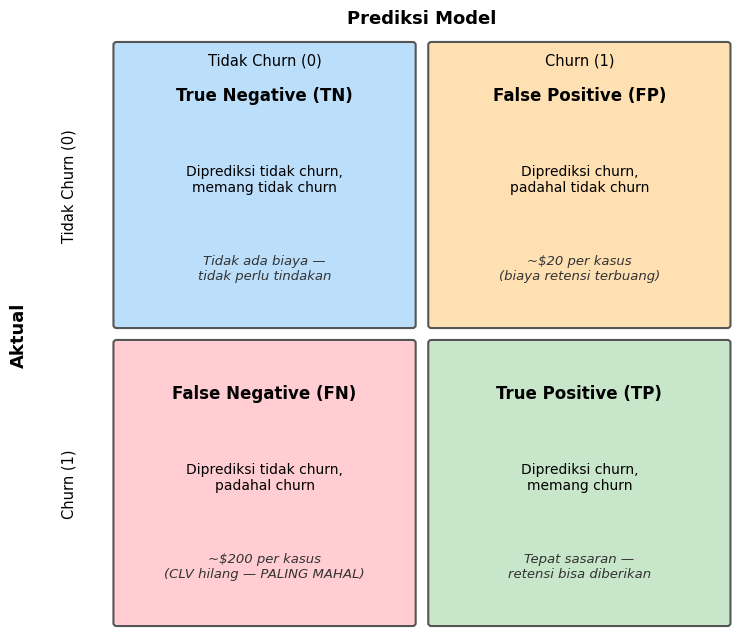

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

cells = [
    (0, 5, '#BBDEFB', 'True Negative (TN)', 'Diprediksi tidak churn,\nmemang tidak churn', 'Tidak ada biaya —\ntidak perlu tindakan'),
    (5, 5, '#FFE0B2', 'False Positive (FP)', 'Diprediksi churn,\npadahal tidak churn', '~$20 per kasus\n(biaya retensi terbuang)'),
    (0, 0, '#FFCDD2', 'False Negative (FN)', 'Diprediksi tidak churn,\npadahal churn', '~$200 per kasus\n(CLV hilang — PALING MAHAL)'),
    (5, 0, '#C8E6C9', 'True Positive (TP)', 'Diprediksi churn,\nmemang churn', 'Tepat sasaran —\nretensi bisa diberikan'),
]

for x, y, color, title, desc, cost in cells:
    rect = patches.FancyBboxPatch((x+0.15, y+0.15), 4.7, 4.7, boxstyle="round,pad=0.05",
                                    linewidth=1.5, edgecolor='#555', facecolor=color)
    ax.add_patch(rect)
    ax.text(x+2.5, y+4.0, title, ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(x+2.5, y+2.6, desc, ha='center', va='center', fontsize=10)
    ax.text(x+2.5, y+1.1, cost, ha='center', va='center', fontsize=9.5, style='italic', color='#333')

ax.text(5, 10.3, 'Prediksi Model', ha='center', va='center', fontsize=13, fontweight='bold')
ax.text(2.5, 9.6, 'Tidak Churn (0)', ha='center', va='center', fontsize=10.5)
ax.text(7.5, 9.6, 'Churn (1)', ha='center', va='center', fontsize=10.5)
ax.text(-1.4, 5, 'Aktual', ha='center', va='center', fontsize=13, fontweight='bold', rotation=90)
ax.text(-0.6, 7.5, 'Tidak Churn (0)', ha='center', va='center', fontsize=10.5, rotation=90)
ax.text(-0.6, 2.5, 'Churn (1)', ha='center', va='center', fontsize=10.5, rotation=90)

plt.tight_layout()
plt.show()

Dari keempat kemungkinan hasil prediksi, **False Negative (FN)** adalah kesalahan dengan konsekuensi bisnis paling besar — pelanggan yang akan churn tetapi tidak terdeteksi, sehingga tidak ada kesempatan memberikan penawaran retensi sebelum pelanggan tersebut benar-benar pergi. Sebaliknya, **False Positive (FP)** hanya berarti penawaran retensi diberikan kepada pelanggan yang sebenarnya tidak perlu — biayanya jauh lebih kecil dan lebih mudah ditoleransi.

Bagian ini mengukur ketidakseimbangan biaya tersebut secara lebih konkret, menggunakan **data benchmark industri e-commerce yang telah dipublikasikan** — bukan dihitung langsung dari dataset ini, karena dataset tidak memiliki kolom harga produk atau data finansial perusahaan.

**Customer Lifetime Value (CLV):** rata-rata CLV pada industri e-commerce berkisar antara **$100–$300** ([Digital Applied Customer Lifetime Value Benchmarks](https://www.shopify.com/blog/customer-lifetime-value-industry), via Shopify, 2026). Kami menggunakan nilai tengah dari rentang tersebut, yaitu **$200**, sebagai estimasi CLV.

**Retention Cost / Customer Retention Cost (CRC):** biaya retensi pelanggan pada e-commerce umumnya berkisar antara **$5–$25 per pelanggan** ([Lifesight — Customer Retention Cost](https://lifesight.io/glossary/customer-retention-cost/)). Kami menggunakan **$20**, sedikit di atas nilai tengah rentang tersebut, sebagai pendekatan yang lebih konservatif.

**Perhitungan rasio biaya:**

$$\text{rasio} = \frac{\text{CLV}}{\text{Retention Cost}} = \frac{200}{20} = 10$$
$$\beta = \sqrt{\text{rasio}} = \sqrt{10} \approx 3{,}16$$

Nilai beta ≈ 3,16 dibulatkan menjadi **beta = 3**, sehingga metrik **F3** dipilih sebagai metrik utama untuk *benchmarking* dan pemilihan model.

**Catatan keterbatasan:** angka CLV dan retention cost di atas merupakan rata-rata global/e-commerce Amerika Serikat pada umumnya. Dataset pada proyek ini kemungkinan besar berasal dari India (berdasarkan metode pembayaran `UPI`, `COD`, dan penggunaan `CityTier`), namun kami tidak menemukan data benchmark yang spesifik untuk pasar e-commerce India. Penggunaan angka global sebagai pendekatan merupakan asumsi yang perlu dinyatakan secara eksplisit.

In [3]:
CLV = 200
RETENTION_COST = 20

ratio = CLV / RETENTION_COST
derived_beta = ratio ** 0.5

print(f"cost ratio (FN:FP): {ratio:.2f}")
print(f"derived beta: {derived_beta:.2f}")

cost ratio (FN:FP): 10.00
derived beta: 3.16


Formula F-beta:

$$F_\beta = (1+\beta^2) \times \frac{\text{precision} \times \text{recall}}{(\beta^2 \times \text{precision}) + \text{recall}}$$

Dengan beta = 3, bobot recall terhadap precision di dalam formula menjadi $\beta^2 = 9$ berbanding 1 — artinya **F3 memprioritaskan recall sekitar 9x lebih besar dibanding precision**. Ini sejalan dengan tujuan bisnis: lebih baik model "terlalu agresif" menandai pelanggan sebagai berisiko churn (menghasilkan beberapa false positive yang biayanya kecil) daripada melewatkan pelanggan yang benar-benar akan churn (false negative yang biayanya besar).

**F3 dipakai sebagai metrik utama** di dua tahap: *benchmarking* (kriteria pemilihan model terbaik di antara 5 kandidat) dan evaluasi akhir model terpilih (train vs test).

Meskipun demikian, F3 adalah angka tunggal yang dapat menyembunyikan detail trade-off di baliknya — dua model bisa mencapai F3 yang sama dengan kombinasi precision dan recall yang sangat berbeda. Karena itu, **Precision, Recall, dan F1 tetap dipantau sebagai metrik pendukung** di sepanjang proses *benchmarking* dan evaluasi, agar trade-off yang sebenarnya terjadi — bukan hanya angka F3 akhir — tetap terlihat dan dapat dipertanggungjawabkan.

Langkah-langkah proyek secara keseluruhan:

1. **Data Understanding & Cleaning**

   Memahami arti setiap fitur pada dataset (5.630 baris, 20 kolom), kemudian menangani masalah kualitas data yang ditemukan:
   * Menstandarisasi label kategori yang berbeda penulisan namun bermakna sama (misalnya `CC` dan `Credit Card`).
   * Menghapus data duplikat (5.630 → 5.073 baris) yang identik di seluruh fitur selain `CustomerID`.
   * Mengoreksi *outlier* ekstrem pada `WarehouseToHome` dan menghapus `CustomerID` yang tidak memiliki nilai prediktif.
   * Menentukan strategi penanganan *missing value* (imputasi median), yang dijalankan setelah pembagian data untuk mencegah *data leakage*.

2. **Split Data & Imputasi**

   Membagi data menjadi data train (80%) dan data test (20%) dengan stratifikasi berdasarkan `Churn`, agar proporsi kelas churn tetap konsisten. Nilai median untuk imputasi dihitung hanya dari data train, lalu diterapkan ke data train dan test.

3. **Exploratory Data Analysis (EDA)**

   Menganalisis distribusi `Churn` dan hubungan setiap fitur dengan `Churn` untuk mengidentifikasi faktor-faktor yang membedakan pelanggan yang churn dan tidak churn, serta memahami implikasinya bagi strategi retensi.

4. **Feature Engineering**

   Menyiapkan fitur agar dapat diproses oleh algoritma:
   * *One-Hot Encoding* untuk fitur kategorikal nominal; fitur ordinal (`CityTier`, `SatisfactionScore`) dipertahankan sebagai bilangan bulat karena urutannya sudah sesuai.
   * Memeriksa multikolinearitas antar fitur numerik.
   * *Scaling* (`StandardScaler`) hanya untuk model berbasis jarak/margin (Logistic Regression, SVM), sedangkan model berbasis pohon tidak memerlukannya.
   * Seluruh proses dibungkus dalam `Pipeline` dan `ColumnTransformer` yang di-*fit* hanya pada data train.

5. **Modeling & Evaluasi**

   * Membandingkan lima algoritma dari keluarga yang berbeda (Logistic Regression, Decision Tree, Random Forest, XGBoost, SVM) menggunakan *5-fold Stratified Cross-Validation* dengan metrik F3. Penanganan imbalance menggunakan *class weighting*.
   * Memeriksa *overfitting* dengan membandingkan skor CV, train, dan test.
   * Melakukan *hyperparameter tuning* pada model terbaik dengan `RandomizedSearchCV`, serta menguji apakah penyesuaian *threshold* klasifikasi memberikan perbaikan tambahan.
   * Mengevaluasi model final menggunakan *confusion matrix*, Precision, Recall, F1, dan F3.

6. **Interpretasi & Dampak Bisnis**

   Menginterpretasikan fitur-fitur yang paling berpengaruh terhadap prediksi churn (*feature importance*) dan membandingkannya dengan temuan EDA, mengestimasi dampak biaya dari model dibandingkan sebelum tuning dan dibandingkan strategi tanpa model, serta menyusun kesimpulan dan rekomendasi bisnis yang dapat ditindaklanjuti.

### Limitations and Assumptions

- Definisi operasional `Churn` tidak dijelaskan oleh sumber data — kolom ini diperlakukan sebagai label yang sudah ditentukan sebelumnya (lihat penjelasan lebih lanjut pada bagian Data Understanding).
- Satuan `Tenure` tidak dinyatakan secara eksplisit pada data dictionary; diasumsikan dalam satuan **bulan** berdasarkan rentang nilainya (0–61).
- Dua nilai ekstrem pada `WarehouseToHome` (126 dan 127) dikoreksi berdasarkan hipotesis kesalahan tanda desimal; ini merupakan asumsi, bukan fakta yang terkonfirmasi.
- Ditemukan anomali pada `NumberOfAddress` (celah nilai 12–18 yang tidak ada) yang tidak dapat dijelaskan dan dibiarkan apa adanya — keterbatasan pemahaman terhadap proses pengumpulan data asli.
- Perhitungan pada bagian **Analytical Approach** menggunakan mata uang **USD ($)**, mengikuti satuan yang digunakan pada sumber data benchmark (CLV dan Retention Cost). Dataset pada proyek ini kemungkinan besar berasal dari India (berdasarkan metode pembayaran `UPI`, `COD`, dan penggunaan `CityTier`), namun tidak ditemukan data benchmark CLV/Retention Cost yang spesifik untuk pasar e-commerce India, sehingga rasio biaya FN:FP dihitung menggunakan asumsi mata uang dan pasar global sebagai pendekatan.
- Estimasi penghematan pada bagian **Estimasi Dampak Bisnis** mengasumsikan setiap penawaran retensi berhasil mempertahankan pelanggan yang menerimanya dan hanya menghitung biaya kesalahan prediksi (bukan total biaya program retensi); angka sebenarnya bergantung pada tingkat keberhasilan program retensi di lapangan.

## Data Understanding

Dataset yang digunakan berisi data historis perilaku dan karakteristik pelanggan dari sebuah platform e-commerce, termasuk lama berlangganan (`Tenure`), frekuensi transaksi, metode pembayaran yang digunakan, tingkat kepuasan, hingga status apakah pelanggan tersebut akhirnya churn atau tidak. Dengan memahami pola-pola pada data ini, perusahaan dapat mengidentifikasi pelanggan yang berisiko churn lebih awal, sehingga tindakan retensi dapat dilakukan sebelum pelanggan benar-benar berhenti.

In [4]:
df = pd.read_csv('Ecommerce_Dataset.csv')
print(df.shape)
df.head()

(5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


### Data Dictionary

| Kolom | Deskripsi |
|---|---|
| CustomerID | ID unik pelanggan |
| Churn | Status churn pelanggan (1 = churn, 0 = tidak churn) — **target** |
| Tenure | Lama pelanggan terdaftar (dalam bulan) |
| PreferredLoginDevice | Perangkat yang paling sering digunakan untuk login |
| CityTier | Klasifikasi kota tempat tinggal pelanggan (lihat penjelasan di bawah) |
| WarehouseToHome | Jarak gudang ke rumah pelanggan |
| PreferredPaymentMode | Metode pembayaran yang paling sering digunakan |
| Gender | Jenis kelamin pelanggan |
| HourSpendOnApp | Rata-rata jam yang dihabiskan di aplikasi/website |
| NumberOfDeviceRegistered | Jumlah perangkat yang terdaftar pada akun pelanggan |
| PreferedOrderCat | Kategori produk yang paling sering dipesan |
| SatisfactionScore | Skor kepuasan pelanggan |
| MaritalStatus | Status pernikahan pelanggan |
| NumberOfAddress | Jumlah alamat yang terdaftar pada akun pelanggan |
| Complain | Apakah pelanggan pernah mengajukan komplain (1 = ya, 0 = tidak) |
| OrderAmountHikeFromlastYear | Persentase kenaikan jumlah order dibanding tahun lalu |
| CouponUsed | Jumlah kupon yang digunakan dalam sebulan terakhir |
| OrderCount | Jumlah order dalam sebulan terakhir |
| DaySinceLastOrder | Jumlah hari sejak order terakhir |
| CashbackAmount | Rata-rata cashback yang diterima dalam sebulan terakhir |

**Catatan mengenai `Churn`:** dataset ini tidak menyediakan definisi eksplisit mengenai kriteria atau periode observasi yang menentukan status churn seorang pelanggan — kolom `Churn` diberikan sebagai *flag* yang sudah ditentukan sebelumnya oleh sumber data. Sebagai indikasi, jika `Churn` dihitung berdasarkan lamanya waktu sejak order terakhir (`DaySinceLastOrder`), seharusnya pelanggan yang churn memiliki `DaySinceLastOrder` yang lebih tinggi — namun pada kenyataannya justru sebaliknya (dibahas lebih lanjut pada bagian Bivariate Analysis). Hal ini mengindikasikan `Churn` kemungkinan merupakan hasil observasi dari periode/sumber lain yang tidak tercermin langsung pada kolom-kolom lain di dataset ini. Analisis pada notebook ini memperlakukan `Churn` sebagaimana adanya (*ground truth label*), tanpa mencoba mendefinisikan ulang kriterianya.

### Penjelasan `CityTier`

`CityTier` merupakan klasifikasi kota tempat tinggal pelanggan berdasarkan jumlah populasi dan tingkat perkembangan ekonomi/infrastruktur — kategorisasi yang umum digunakan khususnya dalam konteks bisnis dan pemerintahan di India.

- **Tier 1** — kota metropolitan besar (contoh: Delhi, Mumbai, Bangalore), populasi terbesar, infrastruktur paling berkembang, tingkat pendapatan lebih tinggi
- **Tier 2** — kota berukuran menengah, populasi dan perkembangan infrastruktur sedang
- **Tier 3** — kota/kabupaten kecil, populasi lebih rendah, infrastruktur kurang berkembang

`CityTier` bersifat **ordinal** (Tier 1 = paling berkembang → Tier 3 = paling kurang berkembang), sehingga akan diperlakukan sebagai variabel ordinal pada tahap Feature Engineering.

## Data Cleaning

### Inconsistent Category Naming

In [5]:
print(df['PreferredLoginDevice'].unique())
print(df['PreferredPaymentMode'].unique())
print(df['PreferedOrderCat'].unique())

<ArrowStringArray>
['Mobile Phone', 'Phone', 'Computer']
Length: 3, dtype: str
<ArrowStringArray>
['Debit Card', 'UPI', 'CC', 'Cash on Delivery', 'E wallet', 'COD',
 'Credit Card']
Length: 7, dtype: str
<ArrowStringArray>
['Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others', 'Fashion',
 'Grocery']
Length: 6, dtype: str


Terlihat di atas, beberapa kolom kategorikal memiliki label yang berbeda penulisan namun merujuk pada hal yang sama, sehingga perlu distandarisasi:
- `PreferredLoginDevice`: `"Phone"` dan `"Mobile Phone"` digabung menjadi `"Mobile Phone"`.
- `PreferredPaymentMode`: `"CC"` dan `"Credit Card"` digabung menjadi `"Credit Card"`; `"COD"` dan `"Cash on Delivery"` digabung menjadi `"Cash on Delivery"`.
- `PreferedOrderCat`: `"Mobile"` dan `"Mobile Phone"` digabung menjadi `"Mobile Phone"`.

In [6]:
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({'Phone': 'Mobile Phone'})
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'CC': 'Credit Card',
    'COD': 'Cash on Delivery'
})
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})

### Duplicate Data

In [7]:
non_id_cols = [c for c in df.columns if c != 'CustomerID']
full_dupes = df.duplicated(subset=non_id_cols, keep=False)

print(f"duplicate CustomerID count: {df['CustomerID'].duplicated().sum()}")
print(f"full duplicate rows (excluding CustomerID): {full_dupes.sum()}")

churn_summary = pd.DataFrame({
    'group': ['overall (before)', 'duplicate rows', 'non-duplicate rows'],
    'churn_rate': [df['Churn'].mean(), df.loc[full_dupes, 'Churn'].mean(), df.loc[~full_dupes, 'Churn'].mean()]
}).round(4)
display(churn_summary)

duplicate CustomerID count: 0
full duplicate rows (excluding CustomerID): 1114


,group,churn_rate
0,overall (before),0.1684
1,duplicate rows,0.1921
2,non-duplicate rows,0.1625


Pengecekan duplikasi hanya pada kolom `CustomerID` menunjukkan tidak ada nilai yang berulang. Namun, pengecekan pada seluruh kolom lain (selain `CustomerID`) menemukan **1.114 baris (557 pasang) data yang identik di semua fitur**, hanya berbeda pada `CustomerID`-nya. Karena kemungkinan 19 kolom lain (termasuk kolom bernilai kontinu seperti `CashbackAmount` dan `Tenure`) memiliki kombinasi nilai yang identik secara kebetulan sangat kecil, baris-baris ini dianggap sebagai duplikasi data, bukan pelanggan yang benar-benar berbeda.

Baris duplikat akan dihapus (menyisakan kemunculan pertama). Distribusi `Churn` pada baris duplikat sedikit lebih tinggi dibanding baris non-duplikat, namun perbedaan ini kecil dan tidak berdampak signifikan pada rasio churn keseluruhan setelah baris duplikat dihapus.

In [8]:
df = df.drop_duplicates(subset=non_id_cols, keep='first').reset_index(drop=True)

print(f"dataset shape after dropping duplicates: {df.shape}")
print(f"overall churn rate after dropping: {df['Churn'].mean():.4f}")

dataset shape after dropping duplicates: (5073, 20)
overall churn rate after dropping: 0.1658


### Missing Values

In [9]:
missing_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                'OrderAmountHikeFromlastYear', 'CouponUsed',
                'OrderCount', 'DaySinceLastOrder']

missing_summary = df[missing_cols].isnull().sum().to_frame(name='missing_count')
missing_summary['missing_pct'] = (missing_summary['missing_count'] / len(df) * 100).round(2)
display(missing_summary)

display(df[missing_cols].agg(['mean', 'median', 'skew']))

,missing_count,missing_pct
Tenure,231,4.55
WarehouseToHome,221,4.36
HourSpendOnApp,230,4.53
OrderAmountHikeFromlastYear,252,4.97
CouponUsed,210,4.14
OrderCount,243,4.79
DaySinceLastOrder,288,5.68


,Tenure,WarehouseToHome,HourSpendOnApp,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder
mean,10.212929,15.545136,2.929176,15.714582,1.805881,3.093789,4.580982
median,9.000000,13.000000,3.000000,15.000000,1.000000,2.000000,3.000000
skew,0.748344,1.695513,-0.029587,0.788483,2.459945,2.104162,1.218967


Tujuh kolom numerik memiliki *missing value* sebesar 4–6% dari total data.

**Mengapa median, bukan mean?**

Distribusi data yang **right-skewed** artinya sebagian besar nilai berkumpul di angka kecil, namun ada sejumlah nilai ekstrem yang menarik ekor distribusi ke arah kanan. Nilai ekstrem ini menaikkan **mean** secara signifikan sehingga tidak lagi mencerminkan nilai tipikal mayoritas pelanggan. **Median** jauh lebih **robust** terhadap outlier. Ketujuh kolom ini terbukti right-skewed, sehingga median dipilih sebagai strategi imputasi.

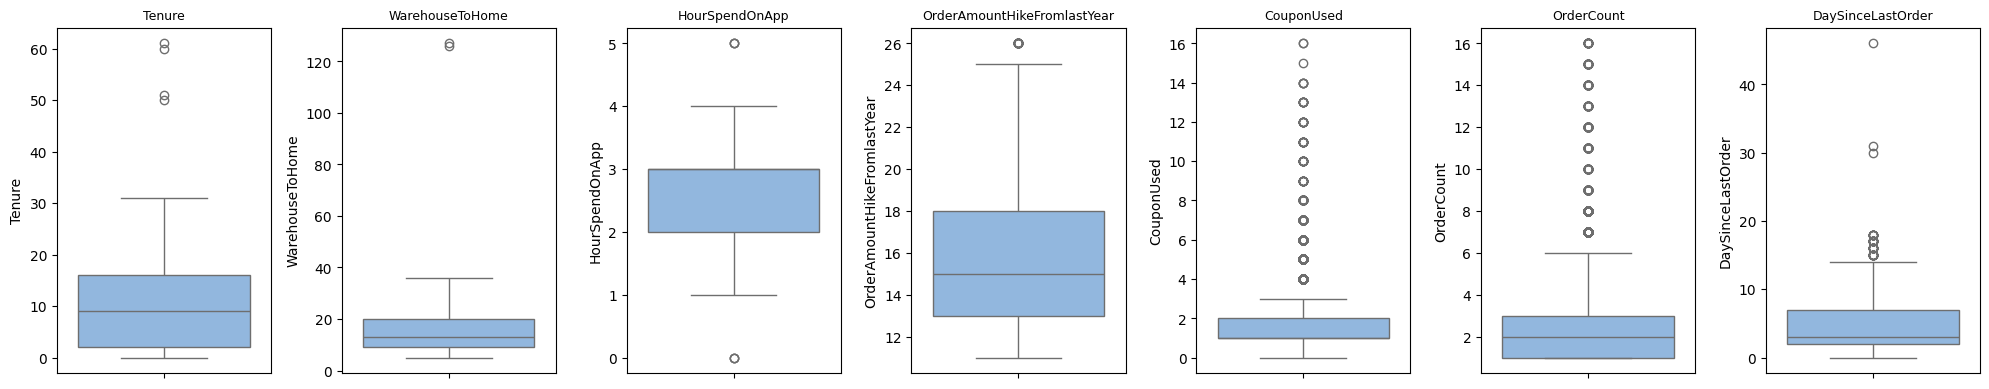

In [10]:
fig, axes = plt.subplots(1, len(missing_cols), figsize=(20, 4))
for ax, col in zip(axes, missing_cols):
    sns.boxplot(y=df[col], ax=ax, color='#85B7EB')
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

Dari boxplot tersebut, kita juga dapat melihat adanya *outliers* pada beberapa kolom — hal ini akan dibahas lebih lanjut pada bagian **Outliers** berikutnya.

**Catatan:** meskipun strategi imputasi (median) sudah ditentukan di sini, **kode imputasi yang sebenarnya baru akan dijalankan pada bagian "Define Feature & Target and Split Data"**, setelah data dibagi menjadi data train dan test, untuk mencegah **data leakage** — median harus dihitung hanya dari data train, kemudian diterapkan ke data train maupun data test.

Kami juga mempertimbangkan menambahkan indikator biner `_was_missing`, namun pola missing pada beberapa kolom (`Tenure`, `WarehouseToHome`, `HourSpendOnApp`) ternyata hanya muncul pada setengah bagian pertama dataset — mengindikasikan artefak dari proses penyusunan data, bukan perilaku pelanggan yang sesungguhnya, sehingga indikator ini tidak digunakan.

In [11]:
df.isna().sum()

CustomerID                       0
Churn                            0
Tenure                         231
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                221
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 230
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    252
CouponUsed                     210
OrderCount                     243
DaySinceLastOrder              288
CashbackAmount                   0
dtype: int64

Terlihat di atas, sudah tidak ada value yang missing.

### Outliers

Pada boxplot di bagian sebelumnya, terlihat adanya outliers di beberapa kolom. Bagian ini membahas masing-masing kolom tersebut, serta kolom numerik lain yang belum diperiksa.

**`WarehouseToHome`:** ditemukan 2 baris dengan nilai **126** dan **127**, jauh di atas nilai tertinggi berikutnya (36). Kemungkinan besar kesalahan input berupa tanda desimal yang hilang (seharusnya 12,6 dan 12,7) — setelah dibagi 10, nilainya kembali wajar. Baris lain pada data ini terlihat normal, sehingga nilai ini **diperbaiki**, bukan dihapus.

In [12]:
outliers = df[df['WarehouseToHome'] > 100]
print(f"jumlah baris outlier: {len(outliers)}")
display(outliers[['WarehouseToHome', 'Tenure', 'CashbackAmount']])

df.loc[df['WarehouseToHome'] > 100, 'WarehouseToHome'] /= 10

print(df['WarehouseToHome'].describe())

jumlah baris outlier: 2


,WarehouseToHome,Tenure,CashbackAmount
1309,126.0,25.0,135
3845,127.0,26.0,160


count    4852.000000
mean       15.498207
std         8.299147
min         5.000000
25%         9.000000
50%        13.000000
75%        20.000000
max        36.000000
Name: WarehouseToHome, dtype: float64


**`Tenure`, `HourSpendOnApp`, `OrderAmountHikeFromlastYear`, `CouponUsed`, `OrderCount`, `DaySinceLastOrder`:** nilai-nilai yang terdeteksi sebagai outlier oleh metode IQR pada kolom-kolom ini masih berada dalam rentang yang masuk akal dan mengikuti pola distribusi yang smooth (tidak ada lompatan nilai yang mencurigakan) — dianggap sebagai variasi data yang wajar, bukan kesalahan, sehingga **tidak diubah**.

**Kolom numerik lain** (`CityTier`, `SatisfactionScore`, `Complain`, `NumberOfDeviceRegistered`, `NumberOfAddress`, `CashbackAmount`) juga diperiksa:

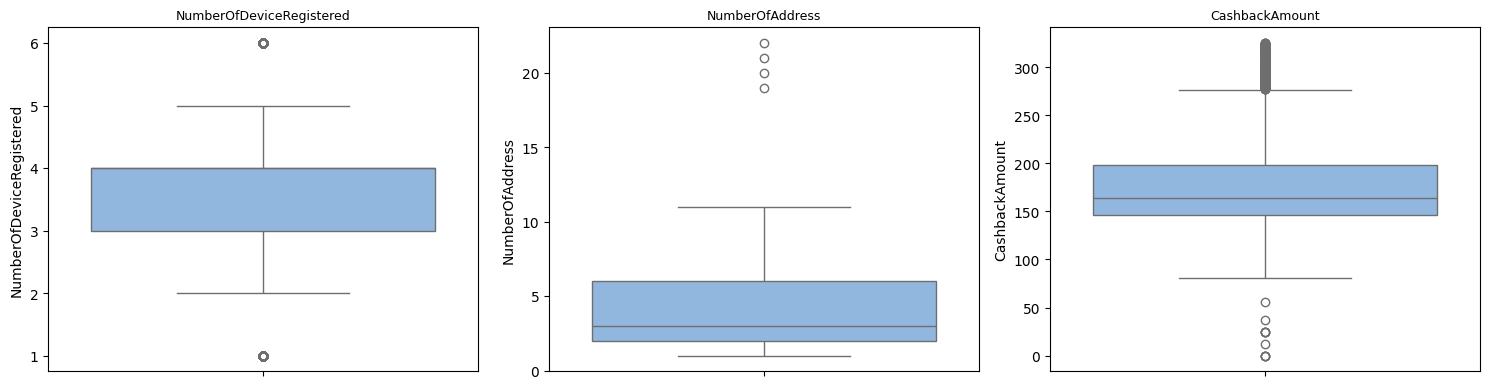

,CityTier,SatisfactionScore,Complain,NumberOfDeviceRegistered,NumberOfAddress,CashbackAmount
count,5073.000000,5073.000000,5073.000000,5073.000000,5073.000000,5073.000000
mean,1.658585,3.027991,0.282673,3.686182,4.194165,177.641238
std,0.919328,1.384629,0.450343,1.029762,2.578949,49.375862
min,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000
25%,1.000000,2.000000,0.000000,3.000000,2.000000,146.000000
50%,1.000000,3.000000,0.000000,4.000000,3.000000,164.000000
75%,3.000000,4.000000,1.000000,4.000000,6.000000,198.000000
max,3.000000,5.000000,1.000000,6.000000,22.000000,325.000000


,count
NumberOfAddress,
1,342
2,1245
3,1150
4,523
5,513
6,344
7,234
8,249
9,212


In [13]:
check_cols = ['CityTier', 'SatisfactionScore', 'Complain',
              'NumberOfDeviceRegistered', 'NumberOfAddress', 'CashbackAmount']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['NumberOfDeviceRegistered', 'NumberOfAddress', 'CashbackAmount']):
    sns.boxplot(y=df[col], ax=ax, color='#85B7EB')
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

display(df[check_cols].describe())
display(df['NumberOfAddress'].value_counts().sort_index().to_frame(name='count'))

- `CityTier`, `SatisfactionScore`, `Complain` — tidak ada outlier terdeteksi (skala tetap dan sempit).
- `NumberOfDeviceRegistered` — outlier terdeteksi hanya karena skala diskret yang sempit (1–6), bukan anomali sesungguhnya.
- `CashbackAmount` — outlier tersebar mengikuti pola spend pelanggan yang wajar.
- `NumberOfAddress` — ditemukan **celah** pada nilai: melompat dari 11 langsung ke 19 (nilai 12–18 tidak ada sama sekali), dengan 19/20/21/22 masing-masing hanya muncul 1 kali. Tidak ditemukan penjelasan kesalahan yang jelas, dan kolom lain pada baris-baris ini terlihat normal. Nilai ini **dipertahankan apa adanya**, dengan mencatat anomali ini secara transparan sebagai temuan yang belum terselesaikan.

### Data Type Mismatch

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5073 entries, 0 to 5072
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5073 non-null   int64  
 1   Churn                        5073 non-null   int64  
 2   Tenure                       4842 non-null   float64
 3   PreferredLoginDevice         5073 non-null   str    
 4   CityTier                     5073 non-null   int64  
 5   WarehouseToHome              4852 non-null   float64
 6   PreferredPaymentMode         5073 non-null   str    
 7   Gender                       5073 non-null   str    
 8   HourSpendOnApp               4843 non-null   float64
 9   NumberOfDeviceRegistered     5073 non-null   int64  
 10  PreferedOrderCat             5073 non-null   str    
 11  SatisfactionScore            5073 non-null   int64  
 12  MaritalStatus                5073 non-null   str    
 13  NumberOfAddress              

Kolom `Tenure`, `HourSpendOnApp`, `OrderAmountHikeFromlastYear`, `CouponUsed`, `OrderCount`, dan `DaySinceLastOrder` tersimpan sebagai `float64` hanya karena sebelumnya memiliki missing value. Setelah imputasi (dilakukan di bagian *Define Feature & Target and Split Data*), seluruh nilainya berupa bilangan bulat, sehingga akan dikonversi menjadi `int64` pada bagian tersebut. `WarehouseToHome` tetap sebagai `float64` karena perbaikan nilai outlier menghasilkan angka desimal yang valid (misal 12.6).

### Drop Irrelevant Features

`CustomerID` merupakan identifier murni tanpa nilai prediktif, sehingga akan dihapus sebelum proses modeling.

In [15]:
customer_ids = df['CustomerID'].copy()  # disimpan agar bisa dipakai lagi saat export (relationship key di Tableau)

df = df.drop(columns=['CustomerID'])
print(df.shape)

(5073, 19)


## Define Feature & Target and Split Data

Sebelum melatih model, dataset perlu dipisahkan menjadi **fitur (X)** dan **target (y)**, kemudian dibagi menjadi **data train** dan **data test**. Pembagian dilakukan dengan **stratifikasi** berdasarkan `Churn`, agar proporsi kelas churn tetap konsisten di kedua bagian data — penting mengingat data ini bersifat imbalanced.

Seperti disebutkan pada bagian Missing Values, imputasi nilai median untuk `Tenure`, `WarehouseToHome`, `HourSpendOnApp`, `OrderAmountHikeFromlastYear`, `CouponUsed`, `OrderCount`, dan `DaySinceLastOrder` **baru dilakukan di sini**, setelah pembagian train-test — median dihitung hanya dari data train, lalu diterapkan ke data train maupun data test, untuk mencegah data leakage.

In [16]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"train shape: {X_train.shape}, test shape: {X_test.shape}")
print(f"churn rate — train: {y_train.mean():.4f}, test: {y_test.mean():.4f}")

median_impute_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                      'OrderAmountHikeFromlastYear', 'CouponUsed',
                      'OrderCount', 'DaySinceLastOrder']

medians = X_train[median_impute_cols].median()

X_train[median_impute_cols] = X_train[median_impute_cols].fillna(medians)
X_test[median_impute_cols] = X_test[median_impute_cols].fillna(medians)

int_cols = ['Tenure', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear',
            'CouponUsed', 'OrderCount', 'DaySinceLastOrder']
X_train[int_cols] = X_train[int_cols].astype(int)
X_test[int_cols] = X_test[int_cols].astype(int)

print(X_train[median_impute_cols].isnull().sum().sum() == 0)
print(X_test[median_impute_cols].isnull().sum().sum() == 0)

# rebuild df (train+test combined) for EDA convenience going forward
df = pd.concat([X_train.assign(Churn=y_train), X_test.assign(Churn=y_test)]).sort_index()

train shape: (4058, 18), test shape: (1015, 18)
churn rate — train: 0.1658, test: 0.1655
True
True


## Exploratory Data Analysis (EDA)

### Univariate Analysis

In [17]:
churn_dist = df['Churn'].value_counts().to_frame(name='count')
churn_dist['proportion'] = (churn_dist['count'] / len(df)).round(4)
display(churn_dist)

,count,proportion
Churn,,
0,4232,0.8342
1,841,0.1658


Dari 5.073 pelanggan, **4.232 (83,42%)** tidak churn dan **841 (16,58%)** churn. Distribusi ini **imbalanced** — kelas churn jauh lebih sedikit dibanding kelas non-churn. Hal ini sudah dipertimbangkan sejak awal proyek: strategi *class weighting* dan pemilihan metrik F3 dipilih justru karena kondisi imbalanced ini, agar model tidak bias hanya memprediksi mayoritas kelas (non-churn).

Distribusi masing-masing fitur individual (numerik maupun kategorikal) tidak dibahas ulang di sini, karena bentuk dan skewness-nya sudah dibahas pada bagian *Data Cleaning* (Missing Values dan Outliers). Bagian selanjutnya (**Bivariate Analysis**) akan langsung mengaitkan setiap fitur dengan `Churn`, karena itulah yang secara langsung menjawab *problem statement* proyek ini.

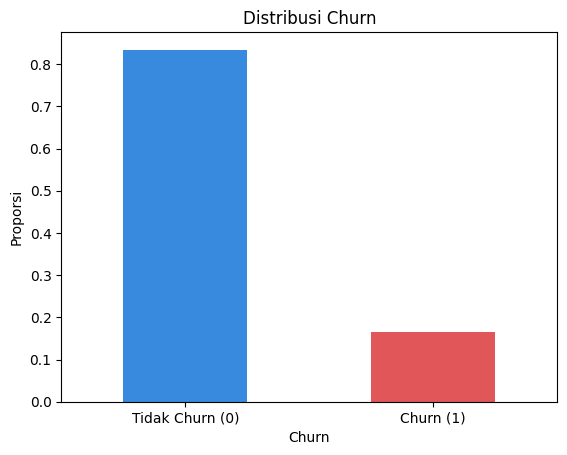

In [18]:
df['Churn'].value_counts(normalize=True).plot(kind='bar', color=['#378ADD','#E15759'])
plt.title('Distribusi Churn')
plt.ylabel('Proporsi')
plt.xticks([0,1], ['Tidak Churn (0)', 'Churn (1)'], rotation=0)
plt.show()

### Bivariate Analysis

In [19]:
numeric_cols = ['Tenure','CityTier','WarehouseToHome','HourSpendOnApp','NumberOfDeviceRegistered',
                'SatisfactionScore','NumberOfAddress','Complain','OrderAmountHikeFromlastYear',
                'CouponUsed','OrderCount','DaySinceLastOrder','CashbackAmount']
cat_cols = ['PreferredLoginDevice','PreferredPaymentMode','Gender','PreferedOrderCat','MaritalStatus']

corr_numeric = (df[numeric_cols + ['Churn']].corr()['Churn']
                 .drop('Churn')
                 .sort_values(key=abs, ascending=False)
                 .round(3)
                 .to_frame(name='correlation'))
display(corr_numeric)

spread = pd.DataFrame({
    'feature': cat_cols,
    'churn_rate_spread': [df.groupby(c)['Churn'].mean().max() - df.groupby(c)['Churn'].mean().min()
                           for c in cat_cols]
}).sort_values('churn_rate_spread', ascending=False).round(3)
display(spread)

,correlation
Tenure,-0.332
Complain,0.249
DaySinceLastOrder,-0.148
CashbackAmount,-0.143
NumberOfDeviceRegistered,0.117
SatisfactionScore,0.101
CityTier,0.098
WarehouseToHome,0.069
NumberOfAddress,0.052
OrderAmountHikeFromlastYear,-0.020


,feature,churn_rate_spread
3,PreferedOrderCat,0.219
4,MaritalStatus,0.154
1,PreferredPaymentMode,0.112
0,PreferredLoginDevice,0.042
2,Gender,0.022


Berdasarkan hasil di atas, fitur dikelompokkan menjadi dua: fitur dengan hubungan **kuat/menarik** terhadap `Churn` dibahas satu per satu di bawah, sementara fitur dengan hubungan **lemah** ditampilkan sebagai satu batch ringkas di bagian akhir, agar pembahasan tetap fokus pada temuan yang benar-benar berdampak.

#### Fitur dengan Hubungan Kuat terhadap Churn

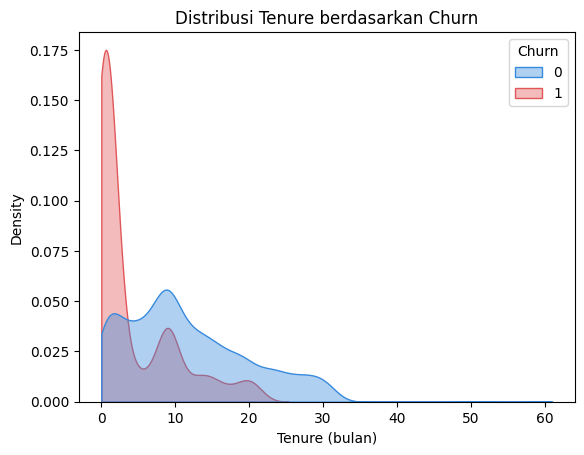

In [20]:
sns.kdeplot(data=df, x='Tenure', hue='Churn', fill=True, common_norm=False,
            palette=['#378ADD','#E15759'], alpha=0.4, clip=(0, df['Tenure'].max()))
plt.title('Distribusi Tenure berdasarkan Churn')
plt.xlabel('Tenure (bulan)')
plt.show()

In [21]:
print(f"{(df.loc[df['Churn'] == 1, 'Tenure'] > 0).mean() * 100:.1f}% pelanggan churn memiliki Tenure > 0")

71.1% pelanggan churn memiliki Tenure > 0


Pelanggan yang churn sangat terkonsentrasi pada tenure rendah (0–2 bulan) — 71,1% pelanggan churn memiliki tenure di atas 0 bulan, namun kepadatannya menurun tajam seiring bertambahnya tenure. Pelanggan baru jauh lebih berisiko churn, mengindikasikan periode awal berlangganan sebagai titik kritis untuk retensi.

Churn,0,1
Complain,,
0,0.892,0.108
1,0.687,0.313


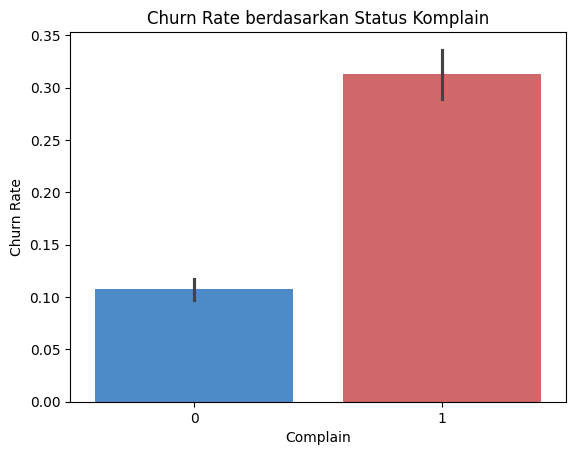

In [22]:
complain_crosstab = pd.crosstab(df['Complain'], df['Churn'], normalize='index').round(3)
display(complain_crosstab)

sns.barplot(x='Complain', y='Churn', hue='Complain', data=df,
            palette=['#378ADD','#E15759'], legend=False)
plt.title('Churn Rate berdasarkan Status Komplain')
plt.ylabel('Churn Rate')
plt.show()

Pelanggan yang pernah komplain churn sebesar 31,3%, hampir 3x lipat dibanding yang tidak pernah komplain (10,8%). Penanganan komplain yang lebih baik berpotensi menjadi strategi retensi langsung.

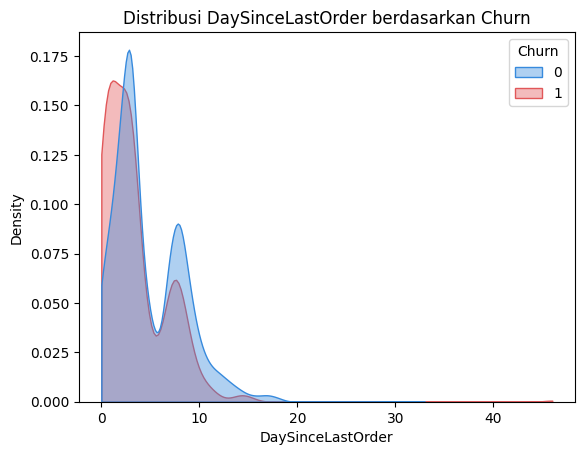

In [23]:
sns.kdeplot(data=df, x='DaySinceLastOrder', hue='Churn', fill=True, common_norm=False,
            palette=['#378ADD','#E15759'], alpha=0.4, clip=(0, df['DaySinceLastOrder'].max()))
plt.title('Distribusi DaySinceLastOrder berdasarkan Churn')
plt.show()

In [24]:
dsl = df.groupby('Churn')['DaySinceLastOrder'].agg(mean='mean', median='median')
dsl['pct_order_le_2_hari'] = df.groupby('Churn')['DaySinceLastOrder'].apply(lambda s: (s <= 2).mean() * 100)
display(dsl.round(2))

,mean,median,pct_order_le_2_hari
Churn,,,
0,4.73,3.0,30.34
1,3.31,3.0,48.51


Menariknya, pelanggan churn justru memiliki rata-rata `DaySinceLastOrder` lebih rendah (3,31 hari) dibanding yang tidak churn (4,73 hari), dan 48,5% pelanggan churn melakukan order terakhir dalam ≤ 2 hari (vs 30,3% pada pelanggan tidak churn) — berlawanan dengan intuisi umum. Hal ini konsisten dengan catatan pada bagian Limitations and Assumptions: `Churn` kemungkinan merupakan label dari observasi periode lain, bukan dihitung langsung dari data historis pada dataset ini.

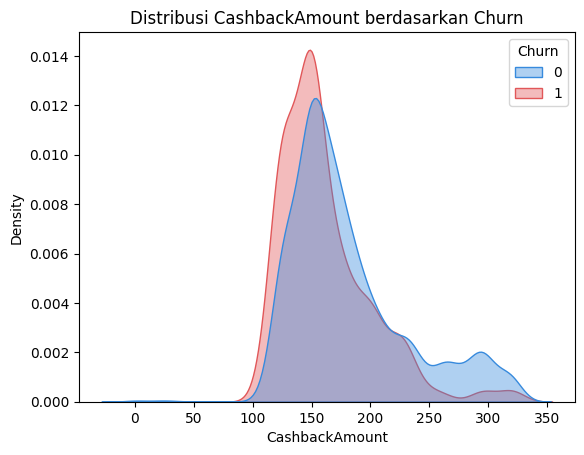

In [25]:
sns.kdeplot(data=df, x='CashbackAmount', hue='Churn', fill=True, common_norm=False,
            palette=['#378ADD','#E15759'], alpha=0.4)
plt.title('Distribusi CashbackAmount berdasarkan Churn')
plt.show()

In [26]:
display(df.groupby('Churn')['CashbackAmount'].agg(['median', 'mean']).round(1))

,median,mean
Churn,,
0,166.0,180.8
1,151.0,161.8


Pelanggan churn cenderung menerima cashback sedikit lebih rendah (median 151 vs 166) — konsisten dengan pola pelanggan yang kurang aktif bertransaksi.

C:\Users\Sagit\AppData\Local\Temp\ipykernel_19056\2137362926.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#378ADD'` for the same effect.

  sns.barplot(x=rates.index, y=rates.values, hue=rates.index, legend=False,
C:\Users\Sagit\AppData\Local\Temp\ipykernel_19056\2137362926.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#378ADD'` for the same effect.

  sns.barplot(x=rates.index, y=rates.values, hue=rates.index, legend=False,
C:\Users\Sagit\AppData\Local\Temp\ipykernel_19056\2137362926.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#378ADD'` for the same effect.

  sns.barplot(x=rates.index, y=rates.values, hue=rates.index, legend=False,


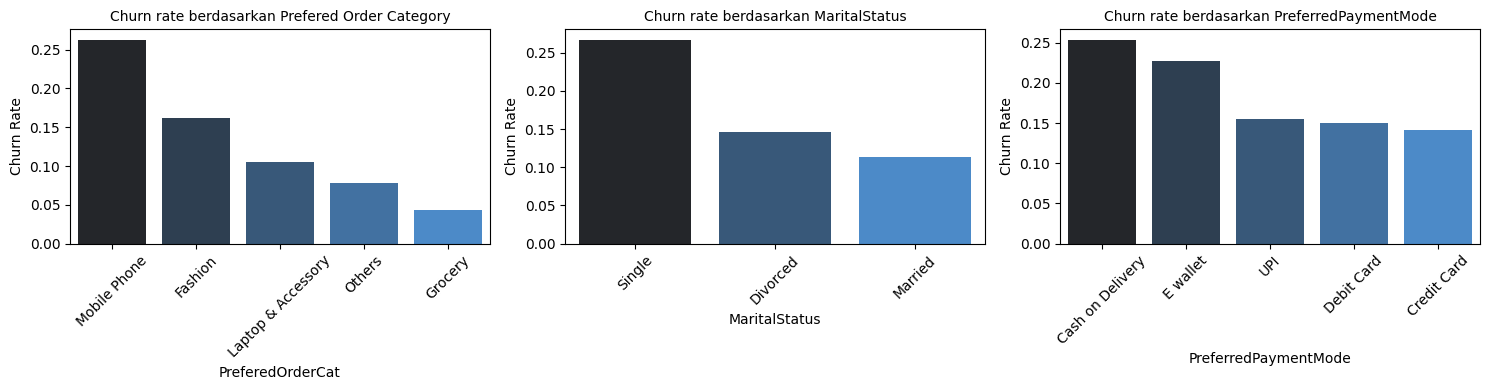

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = {
    'PreferedOrderCat': 'Churn rate berdasarkan Prefered Order Category',
    'MaritalStatus': 'Churn rate berdasarkan MaritalStatus',
    'PreferredPaymentMode': 'Churn rate berdasarkan PreferredPaymentMode',
}
for ax, col in zip(axes, ['PreferedOrderCat', 'MaritalStatus', 'PreferredPaymentMode']):
    rates = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    sns.barplot(x=rates.index, y=rates.values, hue=rates.index, legend=False,
                ax=ax, color='#378ADD')
    ax.set_title(titles[col], fontsize=10)
    ax.set_ylabel('Churn Rate')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [28]:
for col in ['PreferedOrderCat', 'MaritalStatus', 'PreferredPaymentMode']:
    display(df.groupby(col)['Churn'].mean().mul(100).round(1).sort_values(ascending=False).to_frame(name='churn_rate_%'))

,churn_rate_%
PreferedOrderCat,
Mobile Phone,26.3
Fashion,16.3
Laptop & Accessory,10.5
Others,7.9
Grocery,4.4


,churn_rate_%
MaritalStatus,
Single,26.7
Divorced,14.6
Married,11.3


,churn_rate_%
PreferredPaymentMode,
Cash on Delivery,25.4
E wallet,22.8
UPI,15.6
Debit Card,15.0
Credit Card,14.2


- **`PreferedOrderCat`**: kategori `Mobile Phone` memiliki churn rate tertinggi (26,3%), jauh di atas `Grocery` (4,4%). Hal ini kemungkinan mencerminkan perbedaan **pola pembelian**: produk grocery bersifat kebutuhan rutin/berulang, sehingga pelanggan cenderung kembali secara alami tanpa perlu dorongan khusus — sementara pembelian mobile phone bersifat sekali beli dalam jangka waktu lama, sehingga tidak ada alasan transaksional untuk kembali ke platform yang sama, dan pelanggan lebih mudah beralih ke kompetitor saat pembelian berikutnya. **Implikasi bisnis:** kampanye retensi (misal cross-sell aksesoris atau reminder upgrade) mungkin perlu lebih agresif untuk pelanggan dengan kategori favorit mobile phone.
- **`MaritalStatus`**: pelanggan `Single` churn paling tinggi (26,7%) dibanding `Married` (11,3%). Kemungkinan berkaitan dengan **stabilitas rutinitas belanja** — pelanggan yang sudah menikah cenderung memiliki pola belanja rumah tangga yang lebih tetap dan berulang, sementara pelanggan single mungkin lebih eksploratif/sensitif terhadap penawaran platform lain. **Implikasi bisnis:** segmen ini bisa menjadi target program loyalitas yang lebih personal untuk membangun kebiasaan belanja yang lebih konsisten.
- **`PreferredPaymentMode`**: pengguna `Cash on Delivery` churn tertinggi (25,4%), pengguna `Credit Card` terendah (14,2%). Kemungkinan mencerminkan tingkat **keterikatan pada platform** — metode pembayaran yang tersimpan (kartu kredit) menciptakan friksi lebih besar untuk berpindah platform (harus input ulang data pembayaran di tempat lain), sementara COD tidak membutuhkan komitmen digital apa pun terhadap platform, sehingga pelanggan lebih bebas berpindah. **Implikasi bisnis:** mendorong pelanggan COD untuk beralih ke metode pembayaran digital tersimpan berpotensi menjadi salah satu strategi retensi.

#### Fitur dengan Hubungan Lemah terhadap Churn

Fitur-fitur berikut menunjukkan hubungan yang lemah dengan `Churn` (lihat tabel korelasi di awal bagian ini), sehingga tidak dibahas mendalam — namun tetap ditampilkan untuk memastikan seluruh fitur telah diperiksa.

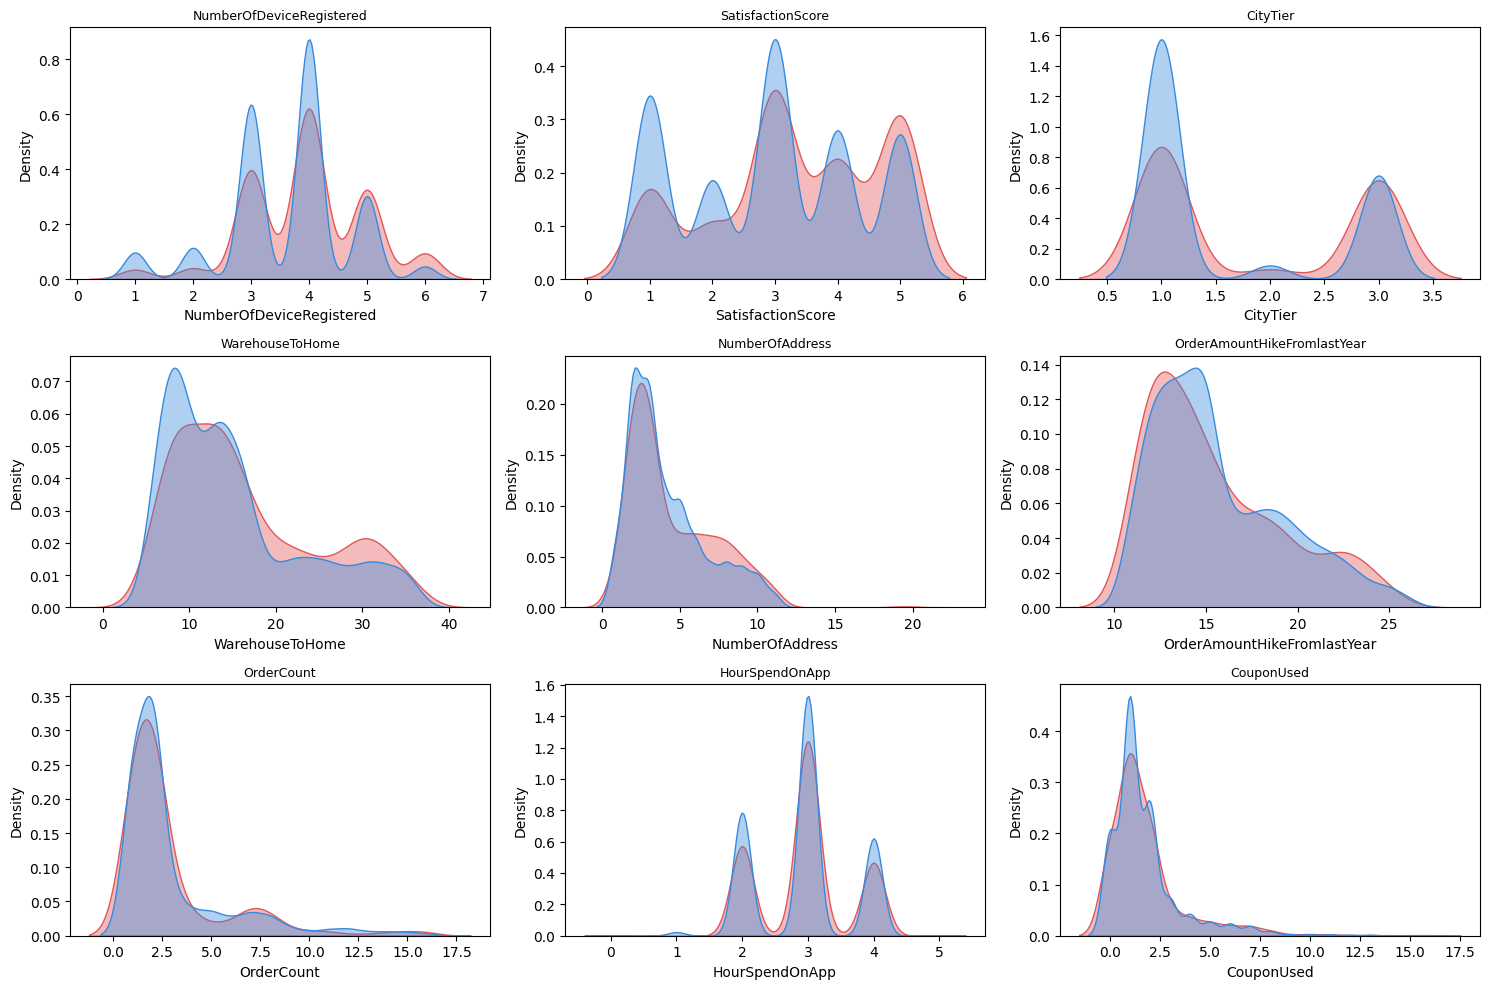

C:\Users\Sagit\AppData\Local\Temp\ipykernel_19056\2220818635.py:20: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#378ADD'` for the same effect.

  sns.barplot(x=rates.index, y=rates.values, hue=rates.index, legend=False,
C:\Users\Sagit\AppData\Local\Temp\ipykernel_19056\2220818635.py:20: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#378ADD'` for the same effect.

  sns.barplot(x=rates.index, y=rates.values, hue=rates.index, legend=False,


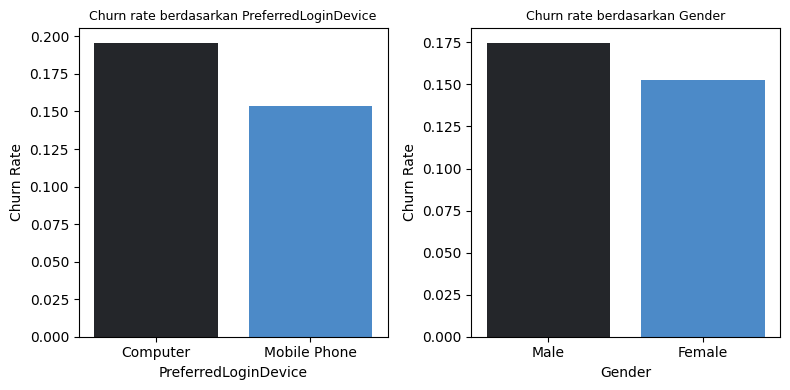

In [29]:
weak_numeric = ['NumberOfDeviceRegistered','SatisfactionScore','CityTier','WarehouseToHome',
                 'NumberOfAddress','OrderAmountHikeFromlastYear','OrderCount',
                 'HourSpendOnApp','CouponUsed']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), weak_numeric):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False,
                palette=['#378ADD','#E15759'], alpha=0.4, ax=ax, legend=False)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
titles = {
    'PreferredLoginDevice': 'Churn rate berdasarkan PreferredLoginDevice',
    'Gender': 'Churn rate berdasarkan Gender',
}
for ax, col in zip(axes, ['PreferredLoginDevice', 'Gender']):
    rates = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    sns.barplot(x=rates.index, y=rates.values, hue=rates.index, legend=False,
                ax=ax, color='#378ADD')
    ax.set_title(titles[col], fontsize=9)
    ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.show()

Tidak ada pola yang cukup jelas atau signifikan pada fitur-fitur ini untuk dijadikan insight tambahan terhadap `Churn`.

## Feature Engineering

### Encoding Fitur Kategorikal

Dataset memiliki dua jenis fitur kategorikal yang perlu diperlakukan berbeda:

- **Ordinal** (`CityTier`, `SatisfactionScore`): sudah berbentuk angka bulat yang merepresentasikan urutan/tingkatan (lihat bagian Data Cleaning). Karena urutannya sudah benar secara numerik, **tidak perlu encoding tambahan** — nilai integer yang ada sudah langsung bisa dipakai model.
- **Nominal** (`PreferredLoginDevice`, `PreferredPaymentMode`, `Gender`, `PreferedOrderCat`, `MaritalStatus`): tidak punya urutan alami, sehingga perlu **One-Hot Encoding** agar model tidak salah menafsirkan kategori sebagai data berurutan (misal `Married` > `Single`).

In [30]:
nominal_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
                 'PreferedOrderCat', 'MaritalStatus']

nunique_nominal = X_train[nominal_cols].nunique().to_frame(name='jumlah_kategori')
display(nunique_nominal)

,jumlah_kategori
PreferredLoginDevice,2
PreferredPaymentMode,5
Gender,2
PreferedOrderCat,5
MaritalStatus,3


Total kategori nominal relatif sedikit (2–5 kategori per kolom), sehingga One-Hot Encoding tidak akan membuat dimensi fitur membengkak berlebihan.

### Cek Multikolinearitas

Sebelum melakukan encoding dan scaling, korelasi antar fitur numerik diperiksa untuk mendeteksi *multikolinearitas* — kondisi di mana dua atau lebih fitur sangat berkorelasi satu sama lain, yang bisa membuat interpretasi koefisien pada model linear (seperti Logistic Regression) menjadi tidak stabil/kurang bisa dipercaya, meskipun performa prediksi model secara keseluruhan biasanya tidak terganggu.

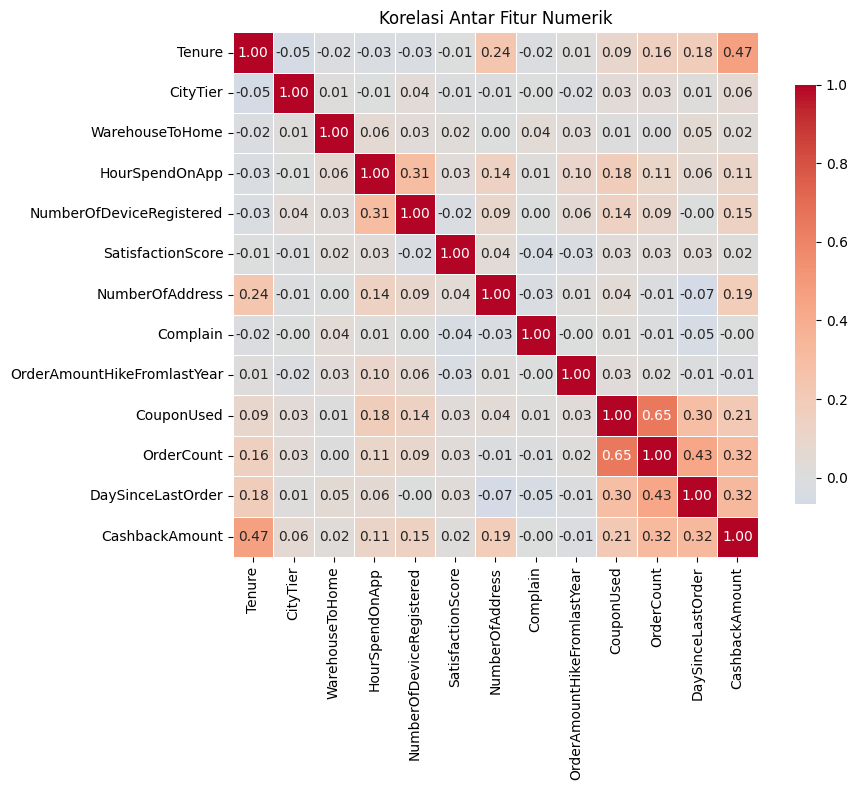

In [31]:
corr = X_train[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Korelasi Antar Fitur Numerik')
plt.tight_layout()
plt.show()

Korelasi tertinggi ditemukan antara `OrderCount` dan `CouponUsed` (**0,65**) — jauh di atas pasangan fitur lainnya (di bawah 0,48). Hal ini masuk akal secara bisnis: pelanggan yang lebih sering berbelanja juga cenderung lebih sering menggunakan kupon.

**Implikasi:** koefisien `OrderCount` dan `CouponUsed` pada **Logistic Regression** perlu diinterpretasikan dengan hati-hati, karena kedua fitur ini saling tumpang tindih secara informasi. Model berbasis pohon (Decision Tree, Random Forest, XGBoost) tidak terpengaruh oleh multikolinearitas ini, karena mekanisme split tidak bergantung pada independensi antar fitur.

### Strategi Scaling

Tidak semua model butuh scaling:

- Model berbasis **jarak/margin** (Logistic Regression, SVM) sensitif terhadap skala fitur numerik → perlu `StandardScaler`.
- Model berbasis **pohon** (Decision Tree, Random Forest, XGBoost) tidak sensitif terhadap skala, karena split dilakukan berdasarkan threshold per fitur, bukan jarak antar titik → scaling tidak diperlukan (bahkan bisa dilewati demi efisiensi dan interpretasi *feature importance* yang tetap dalam satuan asli).

**Penting soal kebocoran data (*data leakage*):** mengikuti pola yang sama seperti imputasi median di bagian Split Data, encoding dan scaling di sini **tidak** langsung diterapkan ke `X_train`/`X_test` sebagai DataFrame baru. Sebagai gantinya, keduanya dibungkus dalam `ColumnTransformer` di dalam `Pipeline` scikit-learn, sehingga proses *fit* (mempelajari kategori unik & parameter scaling) hanya terjadi di data training pada setiap fold cross-validation — bukan di seluruh data sekaligus. Dua `ColumnTransformer` disiapkan agar bisa dipakai ulang oleh model manapun di bagian Model Benchmarking:

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = [c for c in X_train.columns if c not in nominal_cols]

# untuk model berbasis jarak/margin (Logistic Regression, SVM)
preprocessor_scaled = ColumnTransformer([
    ('nominal', OneHotEncoder(handle_unknown='ignore', drop='first'), nominal_cols),
    ('numeric', StandardScaler(), numeric_cols)
])

# untuk model berbasis pohon (Decision Tree, Random Forest, XGBoost)
preprocessor_tree = ColumnTransformer([
    ('nominal', OneHotEncoder(handle_unknown='ignore', drop='first'), nominal_cols),
    ('numeric', 'passthrough', numeric_cols)
])

print(f"nominal_cols ({len(nominal_cols)}): {nominal_cols}")
print(f"numeric_cols ({len(numeric_cols)}): {numeric_cols}")

nominal_cols (5): ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']
numeric_cols (13): ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


## Model Benchmarking

### Mengecek Overfitting

Karena F3 sangat menekankan recall, ada risiko sebuah model terlihat unggul di data training hanya karena ia "menghafal" pola spesifik data tersebut (overfitting), bukan benar-benar menangkap pola yang berlaku umum. Untuk itu, F3 dihitung di **tiga tempat berbeda** untuk setiap model:

- **CV F3** — rata-rata F3 dari 5-fold *Stratified Cross-Validation* di dalam data training saja (setiap fold divalidasi pada bagian yang tidak ikut dilatih). Ini estimasi performa yang tidak bias dan jadi kriteria utama pemilihan model.
- **Train F3** — F3 pada seluruh data training setelah model di-fit penuh. Jika jauh lebih tinggi dari CV/Test, itu tanda model mulai menghafal data training.
- **Test F3** — F3 pada 20% data yang belum pernah disentuh sama sekali sejak split di awal. Ini ukuran generalisasi paling jujur.

Model yang baik seharusnya punya **CV F3 ≈ Test F3** (mengonfirmasi proses benchmarking bisa dipercaya, bukan kebetulan pembagian data), meskipun **Train F3 > Test F3** dalam batas wajar adalah hal normal, terutama untuk model berbasis pohon.

### Model yang Dibandingkan

Lima model dipilih agar mewakili karakteristik algoritma yang beragam (linear, pohon tunggal, ensemble bagging, ensemble boosting, dan margin-based) — bukan lima variasi dari keluarga algoritma yang sama:

1. **Logistic Regression** — *Teknikal:* model linear, cepat dilatih, koefisiennya langsung bisa diartikan sebagai arah & besar pengaruh tiap fitur terhadap log-odds churn. Jadi baseline untuk mengukur apakah model yang lebih kompleks benar-benar memberi nilai tambah. *Bisnis:* paling mudah dijelaskan ke stakeholder non-teknis ("pelanggan yang pernah komplain punya odds churn X kali lebih tinggi"), cocok untuk laporan yang butuh transparansi penuh.

2. **Decision Tree** — *Teknikal:* menangkap hubungan non-linear & interaksi antar fitur tanpa perlu scaling, aturan percabangannya (if-else) bisa divisualisasikan langsung. *Bisnis:* hasilnya paling mudah diterjemahkan tim retensi menjadi SOP konkret (mis. "jika Tenure < 3 bulan DAN pernah Complain → prioritaskan penawaran retensi").

3. **Random Forest** — *Teknikal:* ensemble *bagging* dari ratusan decision tree yang dilatih pada subset data & fitur berbeda, mengurangi varians/overfitting dibanding satu decision tree tunggal sekaligus tetap menangkap non-linearitas. *Bisnis:* lebih stabil untuk dipakai jangka panjang, dan *feature importance*-nya bisa dipakai tim bisnis untuk memprioritaskan driver churn mana yang paling perlu diintervensi.

4. **XGBoost (Gradient Boosting)** — *Teknikal:* pohon dibangun berurutan, setiap pohon baru fokus mengoreksi kesalahan pohon sebelumnya; umumnya performa terbaik untuk data tabular seperti ini, dan punya regularization bawaan (`reg_alpha`/`reg_lambda`) untuk mengendalikan overfitting. *Bisnis:* biasanya prediksinya paling akurat, sehingga potensi penghematan biaya dari rasio CLV:Retention Cost 10:1 yang dihitung sebelumnya paling besar dimanfaatkan.

5. **SVM (RBF Kernel)** — *Teknikal:* mencari *decision boundary* dengan margin maksimum, kernel RBF menangkap pola non-linear kompleks pada fitur yang sudah di-scale. *Bisnis:* jadi pembanding independen dari keluarga algoritma pohon, memastikan model terbaik yang terpilih bukan cuma "kebetulan" cocok dengan satu jenis algoritma saja.

**Penanganan imbalance (16.58% churn):** mengikuti keputusan di Model Selection (*class weighting + threshold tuning, bukan SMOTE*), keempat model pertama memakai parameter bawaan `class_weight='balanced'`. XGBoost tidak punya parameter `class_weight`, sehingga bobot kelas dihitung manual lewat `compute_sample_weight('balanced', ...)` dan dikirim sebagai `sample_weight` saat `.fit()` — secara matematis setara, hanya beda cara scikit-learn/XGBoost menerimanya.

In [33]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import fbeta_score
from sklearn.utils.class_weight import compute_sample_weight

BETA = 3

model_pipelines = {
    'Logistic Regression': Pipeline([
        ('prep', preprocessor_scaled),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('prep', preprocessor_tree),
        ('clf', DecisionTreeClassifier(max_depth=6, min_samples_leaf=20,
                                        class_weight='balanced', random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('prep', preprocessor_tree),
        ('clf', RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10,
                                        class_weight='balanced', random_state=42, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('prep', preprocessor_tree),
        ('clf', XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8,
                               eval_metric='logloss', random_state=42))
    ]),
    'SVM (RBF)': Pipeline([
        ('prep', preprocessor_scaled),
        ('clf', SVC(kernel='rbf', class_weight='balanced', random_state=42))
    ]),
}

# XGBoost butuh sample_weight manual (tidak punya class_weight)
needs_sample_weight = {'XGBoost'}

Setiap model dievaluasi dengan 5-fold `StratifiedKFold` (menjaga proporsi churn 16.58% di tiap fold), lalu di-fit ulang pada seluruh data training untuk membandingkan Train F3 vs Test F3:

In [34]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

benchmark_results = []

for name, pipe in model_pipelines.items():
    cv_scores = []
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        if name in needs_sample_weight:
            sw = compute_sample_weight('balanced', y_fold_train)
            pipe.fit(X_fold_train, y_fold_train, clf__sample_weight=sw)
        else:
            pipe.fit(X_fold_train, y_fold_train)

        val_pred = pipe.predict(X_fold_val)
        cv_scores.append(fbeta_score(y_fold_val, val_pred, beta=BETA))

    # fit ulang di seluruh data training untuk cek Train F3 vs Test F3
    if name in needs_sample_weight:
        sw_full = compute_sample_weight('balanced', y_train)
        pipe.fit(X_train, y_train, clf__sample_weight=sw_full)
    else:
        pipe.fit(X_train, y_train)

    train_f3 = fbeta_score(y_train, pipe.predict(X_train), beta=BETA)
    test_f3 = fbeta_score(y_test, pipe.predict(X_test), beta=BETA)

    benchmark_results.append({
        'Model': name,
        'CV F3 (mean)': round(np.mean(cv_scores), 4),
        'CV F3 (std)': round(np.std(cv_scores), 4),
        'Train F3': round(train_f3, 4),
        'Test F3': round(test_f3, 4),
        'Gap (Train-Test)': round(train_f3 - test_f3, 4),
        'Gap (CV-Test)': round(np.mean(cv_scores) - test_f3, 4),
    })

benchmark_df = pd.DataFrame(benchmark_results).sort_values('CV F3 (mean)', ascending=False).reset_index(drop=True)
display(benchmark_df)

,Model,CV F3 (mean),CV F3 (std),Train F3,Test F3,Gap (Train-Test),Gap (CV-Test)
0,XGBoost,0.8414,0.0345,0.9578,0.8844,0.0735,-0.0430
1,SVM (RBF),0.8203,0.0365,0.9172,0.8609,0.0563,-0.0406
2,Random Forest,0.7942,0.0448,0.8561,0.7850,0.0711,0.0092
3,Decision Tree,0.7611,0.0496,0.7864,0.7219,0.0644,0.0392
4,Logistic Regression,0.7584,0.0361,0.7668,0.7464,0.0203,0.0120


### Interpretasi Hasil Benchmarking

**Urutan performa (berdasarkan CV F3, kriteria utama):** XGBoost > SVM (RBF) > Random Forest > Decision Tree > Logistic Regression.

**Cek overfitting — CV F3 vs Test F3 (kolom `Gap (CV-Test)`):** di semua model, gap antara CV F3 dan Test F3 kecil (sekitar 0,01–0,04), artinya performa di 5-fold cross-validation konsisten dengan performa di data test yang benar-benar belum pernah dilihat model. Ini mengonfirmasi proses benchmarking dapat dipercaya — bukan hasil kebetulan dari satu pembagian data saja.

**Cek overfitting — Train F3 vs Test F3 (kolom `Gap (Train-Test)`):** Logistic Regression punya gap paling kecil (paling tidak overfit, wajar karena model linear sederhana), sementara XGBoost punya gap paling besar. Gap yang lebih besar pada XGBoost merupakan karakteristik umum model *boosting* — cenderung fit sangat rapat ke data training karena pohon-pohon dibangun untuk terus mengoreksi residual/error sisa. Namun karena **CV F3 XGBoost (0,84) tetap konsisten dengan Test F3-nya (0,88)** — bahkan Test F3 sedikit lebih tinggi dari CV F3, mengindikasikan bukan overfitting yang merugikan generalisasi — gap Train-Test yang lebih besar ini lebih tepat dibaca sebagai model yang "percaya diri" pada data training, bukan sebagai kegagalan generalisasi. Gap ini tetap dicatat sebagai catatan untuk diperkecil lebih lanjut lewat regularization pada bagian **Hyperparameter Tuning** berikutnya.

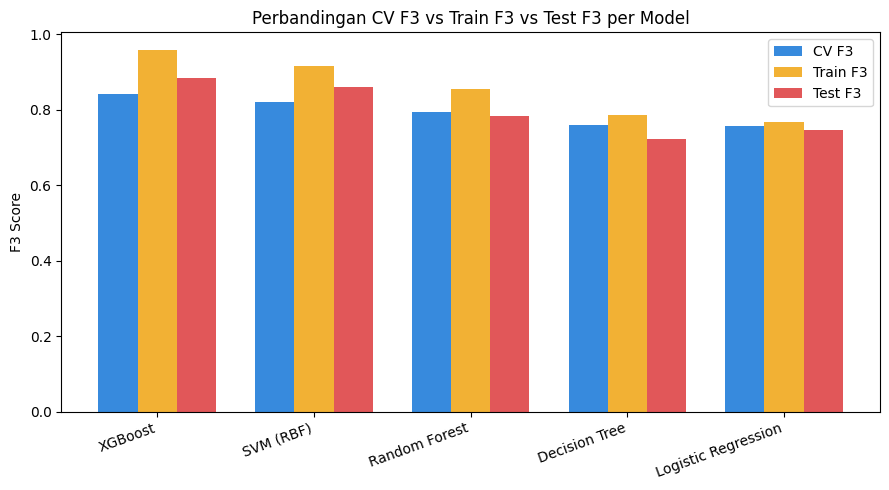

In [35]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(benchmark_df))
width = 0.25

ax.bar(x - width, benchmark_df['CV F3 (mean)'], width, label='CV F3', color='#378ADD')
ax.bar(x, benchmark_df['Train F3'], width, label='Train F3', color='#F2B134')
ax.bar(x + width, benchmark_df['Test F3'], width, label='Test F3', color='#E15759')

ax.set_xticks(x)
ax.set_xticklabels(benchmark_df['Model'], rotation=20, ha='right')
ax.set_ylabel('F3 Score')
ax.set_title('Perbandingan CV F3 vs Train F3 vs Test F3 per Model')
ax.legend()
plt.tight_layout()
plt.show()

### Model Terpilih

**XGBoost** dipilih sebagai model terbaik dari benchmarking ini, dengan justifikasi:

1. **CV F3 tertinggi (0,8414)** di antara 5 model — kriteria utama pemilihan.
2. **Test F3 tertinggi (0,8844)** — juga unggul di data yang benar-benar belum pernah dilihat model.
3. **Gap CV-Test kecil (0,043)** — Test F3 bahkan sedikit lebih tinggi dari CV F3, mengonfirmasi hasil ini bukan kebetulan, model benar-benar generalisasi dengan baik ke data baru, sejalan dengan tujuan bisnis memaksimalkan recall tanpa mengorbankan keandalan prediksi.

Model XGBoost saat ini bekerja lebih baik pada data training dibanding data test — tanda bahwa model mungkin sedikit "menghafal" data training. Hal ini akan dicoba diperkecil pada bagian **Hyperparameter Tuning** berikutnya, dengan tujuan membuat model sedikit lebih "hati-hati" agar prediksinya lebih bisa diandalkan pada pelanggan baru.

### Confusion Matrix

Confusion matrix menampilkan empat kemungkinan hasil prediksi pada data test, masing-masing punya makna bisnis berbeda dalam konteks churn:

- **True Negative (TN)** — pelanggan diprediksi *tidak* churn dan memang tidak churn → tidak butuh tindakan.
- **False Positive (FP)** — pelanggan diprediksi churn padahal sebenarnya tidak → dapat penawaran retensi yang sebenarnya tidak perlu, biayanya kecil (Retention Cost ≈ \$20).
- **False Negative (FN)** — pelanggan diprediksi *tidak* churn padahal sebenarnya churn → paling merugikan, kehilangan pelanggan tanpa sempat diberi penawaran retensi (kehilangan CLV ≈ \$200).
- **True Positive (TP)** — pelanggan diprediksi churn dan memang churn → tepat sasaran, retensi bisa diberikan sebelum pelanggan benar-benar pergi.

Karena metrik F3 dipilih justru untuk menekan FN sebanyak mungkin (dengan konsekuensi FP yang lebih banyak juga wajar), confusion matrix di sini jadi cara paling langsung untuk memverifikasi apakah trade-off itu benar-benar terjadi pada model terpilih.

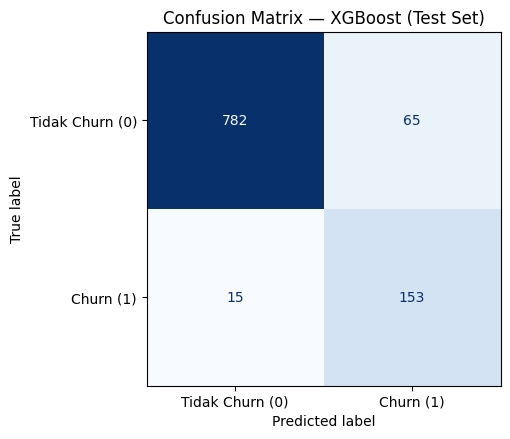

True Negative (TN): 782
False Positive (FP): 65
False Negative (FN): 15
True Positive (TP): 153


In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model_name = benchmark_df.iloc[0]['Model']  # XGBoost, urutan teratas hasil benchmarking
best_pipeline = model_pipelines[best_model_name]

y_test_pred = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Churn (0)', 'Churn (1)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title(f'Confusion Matrix — {best_model_name} (Test Set)')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negative (TN): {tn}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f"True Positive (TP): {tp}")

Untuk konteks perbandingan, berikut confusion matrix kelima model pada data test yang sama — memperlihatkan secara visual bagaimana masing-masing model menyeimbangkan FN vs FP:

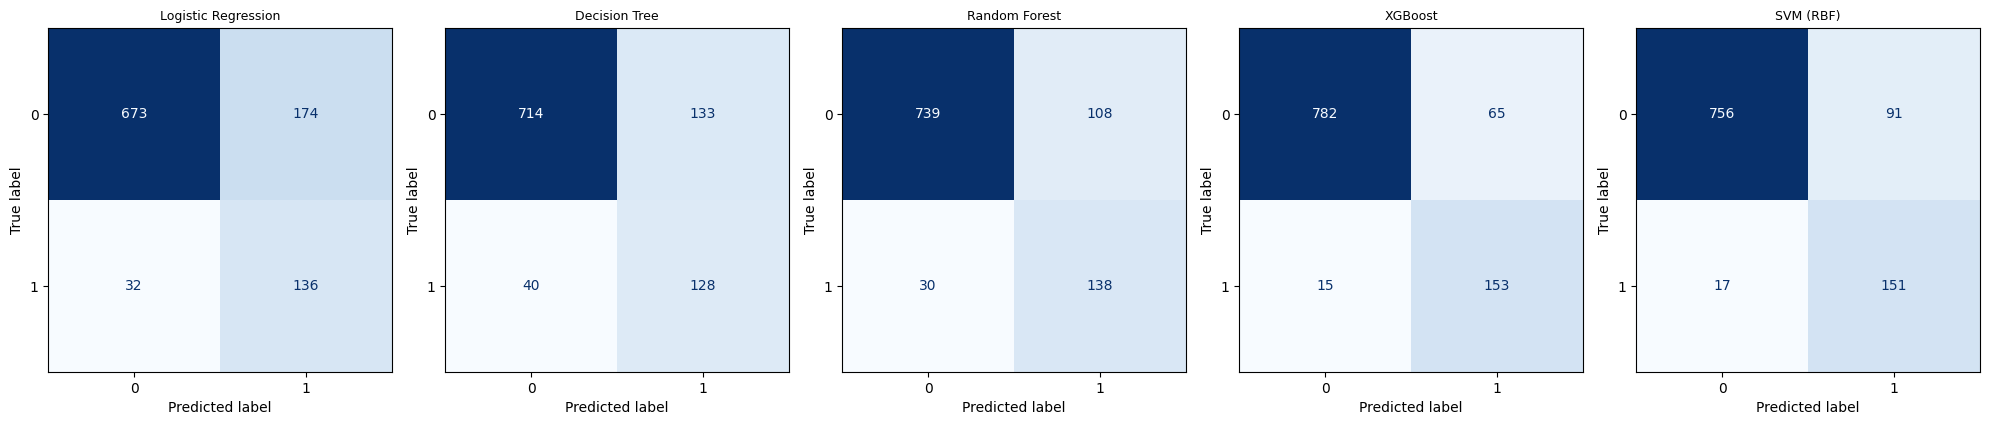

In [37]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, pipe) in zip(axes, model_pipelines.items()):
    pred = pipe.predict(X_test)
    cm_i = confusion_matrix(y_test, pred)
    disp_i = ConfusionMatrixDisplay(confusion_matrix=cm_i, display_labels=['0', '1'])
    disp_i.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(name, fontsize=9)
plt.tight_layout()
plt.show()

### Evaluasi Metrik: Precision, Recall, F1, F3

Selain F3 (metrik utama untuk pemilihan model), empat metrik berikut dihitung untuk gambaran evaluasi yang lebih lengkap pada model terpilih:

- **Precision** = TP / (TP + FP) — dari semua pelanggan yang diprediksi churn, berapa persen yang benar-benar churn. Precision rendah berarti banyak penawaran retensi "terbuang" ke pelanggan yang sebenarnya tidak akan churn.
- **Recall** = TP / (TP + FN) — dari semua pelanggan yang benar-benar churn, berapa persen berhasil terdeteksi model. Ini metrik paling kritis secara bisnis di proyek ini, karena FN adalah kesalahan paling mahal (kehilangan CLV ≈ \$200).
- **F1** = rata-rata harmonik precision & recall dengan bobot **sama besar** — ditampilkan sebagai pembanding netral untuk menunjukkan seberapa jauh F3 "menggeser" preferensi ke arah recall dibanding F1 standar.
- **F3** = metrik utama proyek ini (bobot recall ≈ 9x precision, lihat bagian Model Benchmarking).

Keempatnya dihitung di **train dan test** sekaligus, supaya konsisten dengan pengecekan overfitting yang sudah dilakukan di bagian Model Benchmarking.

In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_train_pred = best_pipeline.predict(X_train)

eval_metrics = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1', 'F3'],
    'Train': [
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
        fbeta_score(y_train, y_train_pred, beta=BETA),
    ],
    'Test': [
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        fbeta_score(y_test, y_test_pred, beta=BETA),
    ],
}).round(4)
eval_metrics['Gap (Train-Test)'] = (eval_metrics['Train'] - eval_metrics['Test']).round(4)

print(f"Model: {best_model_name}")
display(eval_metrics)

Model: XGBoost


,Metric,Train,Test,Gap (Train-Test)
0,Precision,0.8007,0.7018,0.0989
1,Recall,0.9792,0.9107,0.0685
2,F1,0.8810,0.7927,0.0883
3,F3,0.9578,0.8844,0.0734


**Interpretasi:** Recall pada test set jauh lebih tinggi dibanding Precision — persis seperti yang diharapkan dari pemilihan metrik F3, model "sengaja" dibuat lebih agresif menandai pelanggan berisiko churn walau harus mengorbankan sejumlah false positive. F3 (test) berada jauh di atas F1 (test), mengonfirmasi bobot recall yang jauh lebih besar benar-benar tercermin di hasil akhir model, bukan hanya di rumus. Gap Train-Test pada Recall dan F3 sejalan dengan temuan overfitting ringan di bagian Model Benchmarking, dan tetap menjadi fokus perbaikan di Hyperparameter Tuning berikutnya.

## Hyperparameter Tuning

### Strategi Tuning

Berdasarkan hasil **Model Benchmarking**, XGBoost terpilih sebagai model terbaik. Tuning hanya difokuskan pada model ini (bukan kelima model) — pendekatan yang lazim dilakukan di industri karena computationally lebih efisien dan langsung menyasar model yang akan dipakai untuk deployment.

Pendekatan yang dipakai:
- **RandomizedSearchCV** dipilih dibanding `GridSearchCV` karena ruang pencarian (search space) cukup besar (9 hyperparameter) — random search terbukti secara empiris menemukan kombinasi yang kompetitif dengan biaya komputasi jauh lebih rendah dibanding grid search penuh.
- **Scoring**: F3 (`fbeta_score` dengan `beta=3`) yang dibungkus lewat `make_scorer`, konsisten dengan metrik utama yang dipakai sejak bagian Model Benchmarking.
- **Cross-validation**: `StratifiedKFold` 5-fold dengan `random_state=42` yang sama seperti benchmarking (variabel `skf`), agar CV F3 hasil tuning bisa dibandingkan secara adil (*apples-to-apples*) dengan CV F3 baseline (0,8402).
- **Sample weight**: tetap memakai `compute_sample_weight('balanced', ...)` yang dikirim lewat `fit_params`, bukan `scale_pos_weight` — scikit-learn otomatis mengiris (*slice*) array `sample_weight` sesuai index tiap fold CV, sehingga cara penanganan *imbalance* tetap konsisten dengan bagian benchmarking.
- **Parameter yang dituning**: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree` (parameter umum), ditambah `min_child_weight`, `gamma`, `reg_alpha`, `reg_lambda` — empat parameter terakhir ini secara khusus menyasar catatan pada bagian **Interpretasi Hasil Benchmarking**: memperkecil gap Train-Test XGBoost lewat regularization, tanpa mengorbankan banyak CV F3.

In [39]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer

f3_scorer = make_scorer(fbeta_score, beta=BETA)

xgb_pipeline = Pipeline([
    ('prep', preprocessor_tree),
    ('clf', XGBClassifier(eval_metric='logloss', random_state=42))
])

param_distributions = {
    'clf__n_estimators': [100, 200, 300, 400, 500],
    'clf__max_depth': [2, 3, 4, 5, 6],
    'clf__learning_rate': [0.01, 0.02, 0.03, 0.05, 0.08, 0.1],
    'clf__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'clf__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'clf__min_child_weight': [1, 3, 5, 7, 10],
    'clf__gamma': [0, 0.1, 0.3, 0.5, 1],
    'clf__reg_alpha': [0, 0.01, 0.1, 0.5, 1, 2],
    'clf__reg_lambda': [1, 1.5, 2, 3, 5],
}

sw_train_full = compute_sample_weight('balanced', y_train)

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=60,
    scoring=f3_scorer,
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=0,
    refit=True,
)

random_search.fit(X_train, y_train, clf__sample_weight=sw_train_full)

baseline_cv_f3 = benchmark_df.loc[benchmark_df['Model'] == 'XGBoost', 'CV F3 (mean)'].values[0]

print(f"Baseline CV F3 (parameter default): {baseline_cv_f3:.4f}")
print(f"Best CV F3 (setelah tuning)       : {random_search.best_score_:.4f}")
print("\nBest hyperparameters:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

Baseline CV F3 (parameter default): 0.8414
Best CV F3 (setelah tuning)       : 0.8791

Best hyperparameters:
  clf__subsample: 0.8
  clf__reg_lambda: 3
  clf__reg_alpha: 0.1
  clf__n_estimators: 500
  clf__min_child_weight: 1
  clf__max_depth: 6
  clf__learning_rate: 0.03
  clf__gamma: 0.3
  clf__colsample_bytree: 0.6


### Interpretasi Hasil Tuning

`RandomizedSearchCV` (60 kombinasi acak dari total ruang pencarian) menemukan CV F3 sebesar **0,8791** — naik dari **0,8414** pada parameter default (**+0,0377**), tanpa mengubah struktur pipeline atau strategi penanganan *imbalance* sama sekali.

Kombinasi parameter terbaik: `n_estimators=500`, `max_depth=6`, `learning_rate=0.03`, `subsample=0.8`, `colsample_bytree=0.6`, `min_child_weight=1`, `gamma=0.3`, `reg_alpha=0.1`, `reg_lambda=3`.

Dibanding parameter default (`max_depth=4`, `learning_rate=0.05`, `n_estimators=300`, `colsample_bytree=0.8`, tanpa regularization tambahan), model hasil tuning memakai pohon yang lebih dalam dan lebih banyak boosting round (`max_depth` dan `n_estimators` sama-sama mencapai batas atas ruang pencarian), namun diimbangi *learning rate* yang lebih kecil dan regularization yang lebih kuat: `reg_lambda` naik dari 1 menjadi 3, `reg_alpha` dari 0 menjadi 0,1, dan `gamma` dari 0 menjadi 0,3.

In [40]:
tuned_pipeline = random_search.best_estimator_

train_f3_tuned = fbeta_score(y_train, tuned_pipeline.predict(X_train), beta=BETA)
test_f3_tuned = fbeta_score(y_test, tuned_pipeline.predict(X_test), beta=BETA)

baseline_row = benchmark_df[benchmark_df['Model'] == 'XGBoost'].iloc[0]

comparison_df = pd.DataFrame({
    'Tahap': ['Sebelum Tuning (default)', 'Setelah Tuning (RandomizedSearchCV)'],
    'CV F3': [baseline_row['CV F3 (mean)'], round(random_search.best_score_, 4)],
    'Train F3': [baseline_row['Train F3'], round(train_f3_tuned, 4)],
    'Test F3': [baseline_row['Test F3'], round(test_f3_tuned, 4)],
    'Gap (Train-Test)': [baseline_row['Gap (Train-Test)'], round(train_f3_tuned - test_f3_tuned, 4)],
})
display(comparison_df)

,Tahap,CV F3,Train F3,Test F3,Gap (Train-Test)
0,Sebelum Tuning (default),0.8414,0.9578,0.8844,0.0735
1,Setelah Tuning (RandomizedSearchCV),0.8791,0.9904,0.9176,0.0728


Tuning meningkatkan **Test F3 dari 0,8844 menjadi 0,9176 (+0,0332)**, dan **CV F3 dari 0,8414 menjadi 0,8791 (+0,0377)** — peningkatan yang konsisten di kedua metrik, bukan sekadar kebetulan pada satu pembagian data saja.

Namun, target awal untuk memperkecil gap Train-Test **tidak tercapai**: gap nyaris tidak berubah (0,0735 menjadi 0,0728) karena F3 pada data train ikut naik menjadi 0,9904. Artinya tuning meningkatkan performa pada data yang belum pernah dilihat model, tetapi tidak membuat model lebih "hati-hati" terhadap data training. Karena CV F3 dan Test F3 tetap konsisten, gap ini dibaca sebagai karakteristik model *boosting*, bukan tanda gagal generalisasi.

**Model hasil tuning (`tuned_pipeline`) inilah yang dipakai sebagai model final** pada seluruh bagian evaluasi dan penyimpanan model berikutnya.

### Confusion Matrix — Model Final (Setelah Tuning)

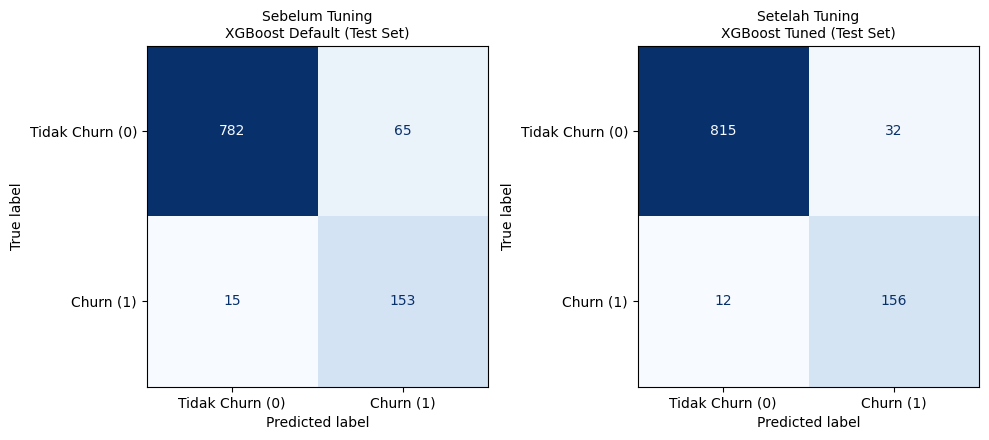

,Sebelum Tuning,Setelah Tuning,Perubahan
True Negative (TN),782,815,33
False Positive (FP),65,32,-33
False Negative (FN),15,12,-3
True Positive (TP),153,156,3


In [41]:
y_test_pred_final = tuned_pipeline.predict(X_test)
cm_final = confusion_matrix(y_test, y_test_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, cm_i, title in zip(
    axes,
    [cm, cm_final],
    ['Sebelum Tuning\nXGBoost Default (Test Set)', 'Setelah Tuning\nXGBoost Tuned (Test Set)']
):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_i, display_labels=['Tidak Churn (0)', 'Churn (1)'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.show()

tn_f, fp_f, fn_f, tp_f = cm_final.ravel()

cm_compare = pd.DataFrame(
    {'Sebelum Tuning': cm.ravel(), 'Setelah Tuning': cm_final.ravel()},
    index=['True Negative (TN)', 'False Positive (FP)', 'False Negative (FN)', 'True Positive (TP)']
)
cm_compare['Perubahan'] = cm_compare['Setelah Tuning'] - cm_compare['Sebelum Tuning']
display(cm_compare)

Dibanding model sebelum tuning (TN=782, FP=65, FN=15, TP=153), model final berhasil menekan **FP dari 65 menjadi 32** dan **FN dari 15 menjadi 12** — keduanya membaik secara bersamaan, bukan sekadar *trade-off* satu arah. Ini penting secara bisnis karena kedua kesalahan punya biaya nyata: setiap FP adalah penawaran retensi (~\$20) yang terbuang ke pelanggan yang sebenarnya tidak akan churn, sementara setiap FN adalah pelanggan yang seharusnya diselamatkan (nilai ~\$200) namun lolos dari deteksi model.

### Evaluasi Metrik Final: Precision, Recall, F1, F3

In [42]:
y_train_pred_final = tuned_pipeline.predict(X_train)

eval_metrics_final = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1', 'F3'],
    'Train': [
        precision_score(y_train, y_train_pred_final),
        recall_score(y_train, y_train_pred_final),
        f1_score(y_train, y_train_pred_final),
        fbeta_score(y_train, y_train_pred_final, beta=BETA),
    ],
    'Test': [
        precision_score(y_test, y_test_pred_final),
        recall_score(y_test, y_test_pred_final),
        f1_score(y_test, y_test_pred_final),
        fbeta_score(y_test, y_test_pred_final, beta=BETA),
    ],
}).round(4)
eval_metrics_final['Gap (Train-Test)'] = (eval_metrics_final['Train'] - eval_metrics_final['Test']).round(4)

print("Model: XGBoost (tuned)")
display(eval_metrics_final)

metric_compare = eval_metrics[['Metric', 'Test']].rename(columns={'Test': 'Test (sebelum tuning)'}).copy()
metric_compare['Test (setelah tuning)'] = eval_metrics_final['Test'].values
metric_compare['Peningkatan'] = (metric_compare['Test (setelah tuning)'] - metric_compare['Test (sebelum tuning)']).round(4)
display(metric_compare)

Model: XGBoost (tuned)


,Metric,Train,Test,Gap (Train-Test)
0,Precision,0.9119,0.8298,0.0821
1,Recall,1.0000,0.9286,0.0714
2,F1,0.9539,0.8764,0.0775
3,F3,0.9904,0.9176,0.0728


,Metric,Test (sebelum tuning),Test (setelah tuning),Peningkatan
0,Precision,0.7018,0.8298,0.1280
1,Recall,0.9107,0.9286,0.0179
2,F1,0.7927,0.8764,0.0837
3,F3,0.8844,0.9176,0.0332


Setelah tuning, seluruh metrik pada data test meningkat dibanding sebelum tuning:
- **Precision**: 0,7018 → 0,8298 (+0,1280)
- **Recall**: 0,9107 → 0,9286 (+0,0179)
- **F1**: 0,7927 → 0,8764 (+0,0837)
- **F3**: 0,8844 → 0,9176 (+0,0332)

Peningkatan Precision jauh lebih besar dibanding Recall, namun Recall tetap tinggi (92,86%) — artinya tuning berhasil mengurangi *false alarm* secara signifikan **tanpa mengorbankan** kemampuan model mendeteksi pelanggan yang benar-benar akan churn, persis sejalan dengan tujuan bisnis awal: meminimalkan *false negative* tanpa membuat precision terlalu rendah.

### Uji Threshold Tuning

Mengikuti keputusan awal di bagian Model Benchmarking (*class weighting + threshold tuning*), bagian ini menguji apakah mengubah ambang batas klasifikasi (*classification threshold*) dari nilai default 0,5 dapat meningkatkan F3 lebih jauh lagi, di atas hasil hyperparameter tuning sebelumnya.

**Metode:** ambang batas optimal dicari menggunakan probabilitas *out-of-fold* dari 5-fold cross-validation pada data **train saja** (bukan data test), agar pemilihan ambang batas tidak "mengintip" data test — pola yang sama seperti pencegahan data leakage pada bagian-bagian sebelumnya.

In [43]:
from sklearn.base import clone

oof_proba = np.zeros(len(y_train))
for tr_idx, val_idx in skf.split(X_train, y_train):
    X_fold_tr, X_fold_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_fold_tr = y_train.iloc[tr_idx]
    sw = compute_sample_weight('balanced', y_fold_tr)
    fold_pipe = clone(tuned_pipeline)
    fold_pipe.fit(X_fold_tr, y_fold_tr, clf__sample_weight=sw)
    oof_proba[val_idx] = fold_pipe.predict_proba(X_fold_val)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)
f3_by_threshold = [fbeta_score(y_train, (oof_proba >= t).astype(int), beta=BETA) for t in thresholds]
best_threshold = round(float(thresholds[np.argmax(f3_by_threshold)]), 2)

test_proba = tuned_pipeline.predict_proba(X_test)[:, 1]
y_test_pred_thresh = (test_proba >= best_threshold).astype(int)

threshold_compare = pd.DataFrame({
    'Threshold': [0.5, best_threshold],
    'OOF F3 (train)': [
        round(fbeta_score(y_train, (oof_proba >= 0.5).astype(int), beta=BETA), 4),
        round(max(f3_by_threshold), 4)
    ],
    'Test F3': [
        round(fbeta_score(y_test, y_test_pred_final, beta=BETA), 4),
        round(fbeta_score(y_test, y_test_pred_thresh, beta=BETA), 4)
    ],
})
display(threshold_compare)

tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_test_pred_thresh).ravel()
cost_default_thresh = fn_f * CLV + fp_f * RETENTION_COST
cost_thresh = fn_t * CLV + fp_t * RETENTION_COST
print(f"estimasi biaya pada threshold 0.5: ${cost_default_thresh}")
print(f"estimasi biaya pada threshold {best_threshold}: ${cost_thresh}")

,Threshold,OOF F3 (train),Test F3
0,0.50,0.8707,0.9176
1,0.28,0.8945,0.9019


estimasi biaya pada threshold 0.5: $3040
estimasi biaya pada threshold 0.28: $3640


Ambang batas 0,28 tampak lebih baik saat diukur dari OOF F3 pada data train (0,8707 → 0,8945), namun ketika diterapkan pada data test, hasilnya justru **lebih buruk**: Test F3 turun dari 0,9176 menjadi 0,9019, dan estimasi biaya kesalahan naik dari \$3.040 menjadi \$3.640. Menurunkan threshold hanya bisa mengurangi FN dan menambah FP, sehingga kenaikan biaya ini berarti tambahan *false positive* lebih mahal secara total dibanding penghematan dari *false negative* yang berhasil dihindari.

Hal ini masuk akal: `class_weight`/`sample_weight='balanced'` yang sudah dipakai sejak awal sebenarnya **sudah menggeser titik keputusan model ke arah recall** secara implisit selama training. Menurunkan threshold lebih jauh di atas penyesuaian ini membuat model "terlalu agresif," melewati titik optimal yang sebenarnya.

**Kesimpulan:** ambang batas default **0,5 dipertahankan** sebagai model final. Pengujian ini tetap dicantumkan untuk menunjukkan bahwa *threshold tuning* — bagian dari strategi penanganan imbalance yang ditetapkan di awal — sudah diuji secara sistematis, bukan diasumsikan begitu saja, dan hasil negatifnya justru memperkuat validitas pendekatan *class weighting* yang sudah dipakai.

## Feature Importance

Untuk memahami fitur mana yang paling berpengaruh terhadap prediksi model final, berikut *feature importance* bawaan XGBoost (berbasis `gain`), diambil dari step `clf` dalam pipeline setelah nama fitur di-*encode* ulang lewat `OneHotEncoder`.

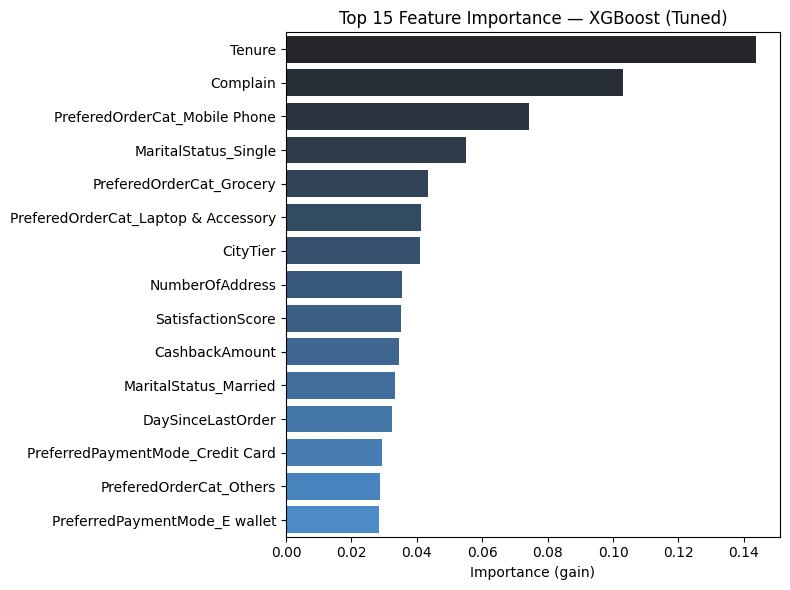

,feature,importance
0,Tenure,0.143857
1,Complain,0.103143
2,PreferedOrderCat_Mobile Phone,0.074438
3,MaritalStatus_Single,0.054893
4,PreferedOrderCat_Grocery,0.043304
5,PreferedOrderCat_Laptop & Accessory,0.041400
6,CityTier,0.041073
7,NumberOfAddress,0.035428
8,SatisfactionScore,0.035051
9,CashbackAmount,0.034514


In [44]:
ohe = tuned_pipeline.named_steps['prep'].named_transformers_['nominal']
ohe_feature_names = list(ohe.get_feature_names_out(nominal_cols))
all_feature_names = ohe_feature_names + numeric_cols

importances = tuned_pipeline.named_steps['clf'].feature_importances_

feat_imp_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

top_n = 15
plt.figure(figsize=(8, 6))
sns.barplot(data=feat_imp_df.head(top_n), x='importance', y='feature',
            hue='feature', legend=False, color='#378ADD')
plt.title(f'Top {top_n} Feature Importance — XGBoost (Tuned)')
plt.xlabel('Importance (gain)')
plt.ylabel('')
plt.tight_layout()
plt.show()

display(feat_imp_df.head(top_n))

**`Tenure`** dan **`Complain`** menjadi dua fitur paling berpengaruh — konsisten dengan temuan pada bagian **EDA (Bivariate Analysis)** sebelumnya, yang menunjukkan pelanggan churn terkonsentrasi pada tenure rendah, dan churn rate pelanggan yang pernah komplain hampir 3x lipat dibanding yang tidak pernah komplain. Kategori `PreferedOrderCat_Mobile Phone` juga masuk 3 besar, sejalan dengan temuan churn rate tertinggi (26,3%) pada kategori tersebut di bagian EDA.

Konsistensi antara *feature importance* model dan pola yang sudah ditemukan secara eksploratif di awal memperkuat kepercayaan bahwa model menangkap hubungan yang secara bisnis masuk akal, bukan pola palsu (*spurious pattern*).

Selain *feature importance* bawaan XGBoost (`gain`), nilai **SHAP (SHapley Additive exPlanations)** juga dihitung sebagai pembanding. Berbeda dengan `gain` — yang mengukur seberapa besar kontribusi sebuah fitur saat dipakai untuk membagi pohon — SHAP mengukur rata-rata kontribusi aktual setiap fitur terhadap *setiap prediksi* pada data test, sehingga lebih mencerminkan dampak fitur secara konsisten di seluruh populasi pelanggan, bukan hanya seberapa sering/menentukan fitur itu dipakai saat membangun pohon.

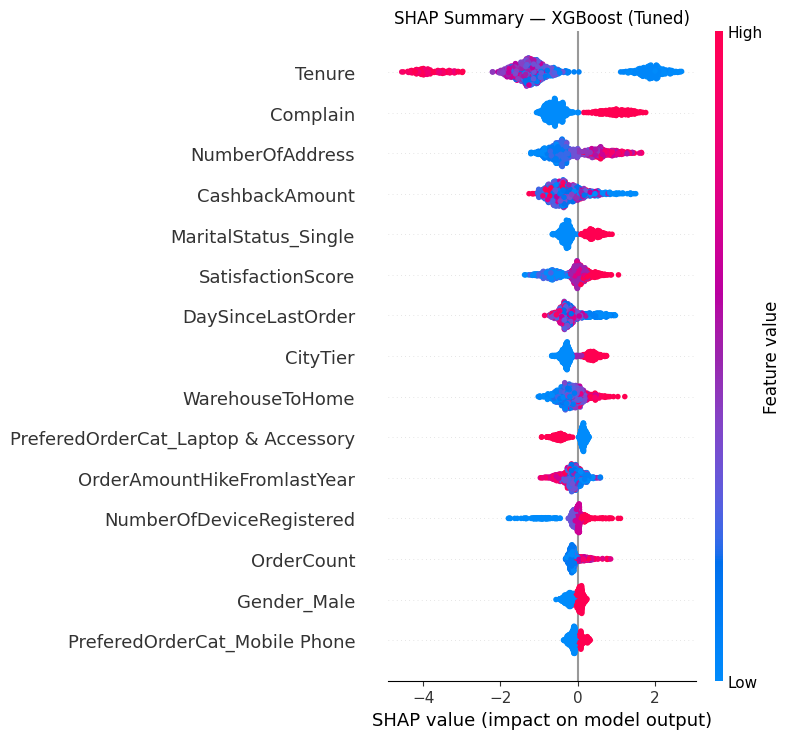

,feature,mean_abs_shap
0,Tenure,1.694248
1,Complain,0.725556
2,NumberOfAddress,0.538310
3,CashbackAmount,0.458391
4,MaritalStatus_Single,0.335249
5,SatisfactionScore,0.324745
6,DaySinceLastOrder,0.324456
7,CityTier,0.324346
8,WarehouseToHome,0.277873
9,PreferedOrderCat_Laptop & Accessory,0.275940


In [45]:
import shap

ohe = tuned_pipeline.named_steps['prep'].named_transformers_['nominal']
ohe_feature_names = list(ohe.get_feature_names_out(nominal_cols))
all_feature_names = ohe_feature_names + numeric_cols

X_test_transformed = pd.DataFrame(
    tuned_pipeline.named_steps['prep'].transform(X_test),
    columns=all_feature_names,
    index=X_test.index
)

explainer = shap.TreeExplainer(tuned_pipeline.named_steps['clf'])
shap_values = explainer.shap_values(X_test_transformed)

shap_imp_df = pd.DataFrame({
    'feature': all_feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test_transformed, max_display=15, show=False)
plt.title('SHAP Summary — XGBoost (Tuned)')
plt.tight_layout()
plt.show()

display(shap_imp_df.head(15))

`Tenure` dan `Complain` tetap menjadi dua fitur paling berpengaruh menurut SHAP, mengonfirmasi hasil dari *feature importance* berbasis `gain` di atas maupun temuan EDA. Pada *summary plot*, titik merah (nilai `Tenure` tinggi) berada di sisi kiri (mendorong prediksi ke arah "tidak churn"), sementara titik biru (`Tenure` rendah) berada di sisi kanan — konsisten dengan temuan bahwa pelanggan baru jauh lebih berisiko churn.

Satu perbedaan menarik dibanding *feature importance* berbasis `gain`: kategori `PreferedOrderCat_Mobile Phone` yang sebelumnya masuk 3 besar berdasarkan `gain`, **tidak masuk 10 besar** berdasarkan SHAP — digantikan oleh `NumberOfAddress` dan `CashbackAmount`. Ini bukan kontradiksi, melainkan perbedaan cara mengukur: `gain` menilai seberapa menentukan sebuah fitur saat dipakai membagi pohon (bisa tinggi meski fitur itu jarang dipakai), sedangkan SHAP menilai rata-rata kontribusi fitur pada **seluruh** prediksi di data test. Dengan kata lain, `PreferedOrderCat_Mobile Phone` sangat menentukan ketika dipakai, namun tidak selalu relevan untuk setiap pelanggan — sementara `NumberOfAddress` dan `CashbackAmount` memberi kontribusi yang lebih konsisten pada pelanggan secara umum.

Konsistensi `Tenure` dan `Complain` di kedua metode, ditambah kesesuaiannya dengan temuan EDA, memperkuat kepercayaan bahwa model menangkap hubungan yang secara bisnis masuk akal, bukan pola palsu (*spurious pattern*). Perbedaan pada fitur-fitur di luar dua itu menunjukkan pentingnya tidak hanya mengandalkan satu metode interpretasi model.

## Estimasi Dampak Bisnis

Menggunakan asumsi `CLV = $200` dan `RETENTION_COST = $20` dari bagian **Analytical Approach**, estimasi biaya kesalahan model pada data test (1.015 pelanggan, 168 di antaranya benar-benar churn) dihitung sebagai `FN x CLV + FP x RETENTION_COST`:

In [46]:
cost_before = fn * CLV + fp * RETENTION_COST
cost_after = fn_f * CLV + fp_f * RETENTION_COST
savings = cost_before - cost_after

cost_compare = pd.DataFrame({
    'Tahap': ['Sebelum Tuning', 'Setelah Tuning'],
    'FN': [fn, fn_f],
    'FP': [fp, fp_f],
    'Estimasi Biaya ($)': [cost_before, cost_after],
})
display(cost_compare)

print(f"Estimasi penghematan biaya pada data test: ${savings} ({savings / cost_before * 100:.1f}% dari biaya sebelum tuning)")

,Tahap,FN,FP,Estimasi Biaya ($)
0,Sebelum Tuning,15,65,4300
1,Setelah Tuning,12,32,3040


Estimasi penghematan biaya pada data test: $1260 (29.3% dari biaya sebelum tuning)


Tuning menekan estimasi biaya kesalahan prediksi dari **\$4.300 menjadi \$3.040** — penghematan **~29%** — hasil dari kombinasi FN yang lebih sedikit (15→12) **dan** FP yang lebih sedikit (65→32) secara bersamaan pada 1.015 pelanggan di data test.

### Perbandingan dengan Strategi Tanpa Model

Selain membandingkan model sebelum dan sesudah tuning, dampak model juga perlu dibandingkan dengan **tidak menggunakan model sama sekali**. Dua strategi pembanding dihitung dengan definisi biaya yang sama (`FN x CLV + FP x RETENTION_COST`):

- **Tidak ada tindakan:** seluruh pelanggan churn hilang tanpa sempat ditawari retensi.
- **Tawarkan retensi ke semua pelanggan:** seluruh churner tertangani, tetapi penawaran juga diberikan kepada pelanggan yang tidak akan churn.

In [47]:
n_churn = int(y_test.sum())
n_non_churn = len(y_test) - n_churn

cost_no_action = n_churn * CLV
cost_offer_all = n_non_churn * RETENTION_COST
cost_model = fn_f * CLV + fp_f * RETENTION_COST

strategy_compare = pd.DataFrame({
    'Strategi': ['Tidak ada tindakan', 'Tawarkan retensi ke semua', 'Dengan model (XGBoost tuned)'],
    'Churn terlewat (FN)': [n_churn, 0, fn_f],
    'Penawaran sia-sia (FP)': [0, n_non_churn, fp_f],
    'Estimasi Biaya Kesalahan ($)': [cost_no_action, cost_offer_all, cost_model],
})
display(strategy_compare)

savings_vs_all = cost_offer_all - cost_model
savings_vs_none = cost_no_action - cost_model
print(f"Penghematan vs tawarkan ke semua: ${savings_vs_all} ({savings_vs_all / cost_offer_all * 100:.1f}%)")
print(f"Penghematan vs tidak ada tindakan: ${savings_vs_none} ({savings_vs_none / cost_no_action * 100:.1f}%)")

# sensitivitas: ikut menghitung biaya penawaran ke churner yang berhasil ditandai
spend_model = cost_model + tp_f * RETENTION_COST
spend_all = cost_offer_all + n_churn * RETENTION_COST
print(f"Penghematan vs tawarkan ke semua, termasuk biaya penawaran ke churner yang ditandai: ${spend_all - spend_model}")

,Strategi,Churn terlewat (FN),Penawaran sia-sia (FP),Estimasi Biaya Kesalahan ($)
0,Tidak ada tindakan,168,0,33600
1,Tawarkan retensi ke semua,0,847,16940
2,Dengan model (XGBoost tuned),12,32,3040


Penghematan vs tawarkan ke semua: $13900 (82.1%)
Penghematan vs tidak ada tindakan: $30560 (91.0%)
Penghematan vs tawarkan ke semua, termasuk biaya penawaran ke churner yang ditandai: $14140


Pada 1.015 pelanggan di data test, biaya kesalahan dengan model hanya **\$3.040**, dibandingkan **\$16.940** jika seluruh pelanggan ditawari retensi, dan **\$33.600** jika tidak ada tindakan sama sekali.

Pembanding yang paling realistis adalah strategi "tawarkan ke semua", karena tanpa model tim retensi umumnya tidak dapat membedakan pelanggan berisiko. Terhadap strategi ini, model menghemat sekitar **\$13.900 (82,1%)**. Jika biaya penawaran kepada churner yang berhasil ditandai (156 x \$20) ikut dihitung di kedua sisi, penghematan menjadi **\$14.140**, sehingga kesimpulannya tidak berubah.

**Asumsi dan batasan:** (1) setiap penawaran retensi diasumsikan berhasil mempertahankan pelanggan yang menerimanya. Pada praktiknya keberhasilannya kurang dari 100%, jadi angka ini adalah batas atas. (2) Hanya biaya kesalahan prediksi yang dihitung (CLV \$200 dan biaya retensi \$20 dari bagian **Analytical Approach**), bukan total biaya program retensi. (3) Angka dihitung pada data test (1.015 pelanggan), bukan seluruh basis pelanggan.

## Kesimpulan dan Rekomendasi

### Kesimpulan

**Model terbaik:** **XGBoost** dengan hyperparameter hasil tuning (`RandomizedSearchCV`) terpilih sebagai model final, setelah dibandingkan dengan 4 algoritma lain (Logistic Regression, Decision Tree, Random Forest, SVM) menggunakan metrik **F3**.

**Cara kerja model (secara konsep):** XGBoost bekerja dengan cara membangun banyak "pohon keputusan" sederhana secara bertahap — setiap pohon baru dibuat khusus untuk memperbaiki kesalahan yang masih dibuat oleh kumpulan pohon sebelumnya. Bayangkan seperti sekelompok orang menebak risiko churn seorang pelanggan secara bergiliran: orang pertama menebak berdasarkan `Tenure` saja, lalu orang kedua melihat kasus-kasus yang masih salah ditebak dan mencoba memperbaikinya dengan mempertimbangkan `Complain`, dan seterusnya. Hasil akhirnya adalah gabungan "suara" dari seluruh pohon tersebut, berupa satu angka probabilitas churn untuk setiap pelanggan — bukan sekadar label "churn" atau "tidak churn".

**Mengapa model ini dapat dipercaya, dan batasannya:** Model diuji pada data yang sama sekali belum pernah dilihat selama training (data test), dan hasilnya (CV F3 0,8791 vs Test F3 0,9176) konsisten — bukan kebetulan dari satu pembagian data saja. Artinya, model cukup andal untuk pelanggan dengan karakteristik serupa dengan data yang dipelajari.

Namun, ada batasan penting yang perlu disadari sebelum model ini digunakan untuk keputusan bisnis nyata:
- Model ini **paling bisa dipercaya untuk pelanggan dengan profil serupa dengan data historis** yang dipakai untuk training. Jika basis pelanggan berubah signifikan (segmen pasar baru, perubahan besar pada kebiasaan belanja, dsb.), performa model berpotensi menurun dan perlu dievaluasi ulang.
- Definisi operasional `Churn` pada dataset ini **tidak diketahui secara pasti** (lihat bagian *Limitations and Assumptions*) — model ini mempelajari pola dari label yang sudah ada, bukan definisi churn yang divalidasi langsung oleh tim bisnis. Sebelum digunakan untuk keputusan nyata, kriteria churn ini **perlu dikonfirmasi ulang** agar hasil model benar-benar menjawab pertanyaan bisnis yang dimaksud.
- Model perlu dipantau dan dilatih ulang secara berkala, karena pola perilaku pelanggan e-commerce dapat berubah dari waktu ke waktu (*concept drift*) — model yang baik hari ini tidak otomatis tetap baik beberapa bulan ke depan.

**Interpretasi bisnis:** Dalam istilah yang lebih sederhana — dari setiap 100 pelanggan yang benar-benar akan churn, model berhasil mendeteksi sekitar **93 di antaranya** (Recall 92,9%), sehingga sangat sedikit pelanggan berisiko yang "lolos" tanpa sempat ditawari retensi. Dari setiap 100 pelanggan yang ditandai model sebagai berisiko churn, sekitar **83 di antaranya memang benar-benar berisiko** (Precision 83,0%) — artinya ada sebagian kecil penawaran retensi yang "terbuang" ke pelanggan yang sebenarnya tidak akan churn, namun ini merupakan trade-off yang disengaja (lihat **Analytical Approach**), karena biaya kehilangan pelanggan jauh lebih besar dibanding biaya penawaran retensi yang meleset. Secara finansial, pada data test estimasi biaya kesalahan model hanya \$3.040, dibandingkan \$16.940 jika seluruh pelanggan ditawari retensi tanpa model, sehingga penghematannya sekitar \$13.900 (82,1%), dengan asumsi penawaran retensi berhasil mempertahankan pelanggan yang ditandai (lihat bagian **Estimasi Dampak Bisnis**).

### Rekomendasi

#### Rekomendasi Bisnis

1. **Program onboarding intensif di bulan-bulan pertama berlangganan** — `Tenure` adalah fitur paling berpengaruh pada kedua metode interpretasi (*gain* maupun SHAP), dan EDA menunjukkan risiko churn tertinggi justru pada pelanggan baru. Ini rekomendasi dengan dasar paling kuat di antara semuanya.
2. **SOP penanganan komplain yang lebih cepat dan personal** — pelanggan yang pernah komplain (`Complain`) churn hampir 3x lipat lebih tinggi dibanding yang tidak, dan fitur ini juga konsisten penting di kedua metode interpretasi.
3. **Pantau dan berikan insentif tambahan pada pelanggan dengan `CashbackAmount` yang cenderung rendah/menurun** — EDA menunjukkan pelanggan churn menerima cashback lebih rendah (median 151 vs 166), dan temuan ini diperkuat oleh SHAP yang menempatkan `CashbackAmount` di 10 besar fitur paling berpengaruh.
4. **Program retensi untuk segmen kategori Mobile Phone perlu divalidasi lebih lanjut sebelum dijadikan prioritas utama** — churn rate tertinggi (26,3%) memang ada pada `PreferedOrderCat = Mobile Phone`, dan fitur ini masuk 3 besar berdasarkan *gain*. Namun, SHAP (lihat bagian **Feature Importance**) menunjukkan kontribusinya tidak sekonsisten `Tenure`/`Complain`/`CashbackAmount` di seluruh populasi pelanggan — sehingga sebaiknya diperlakukan sebagai hipotesis yang perlu divalidasi lebih lanjut (misalnya lewat A/B test skala kecil), bukan rekomendasi utama yang langsung dijalankan penuh.
5. Gunakan **skor probabilitas** model (`predict_proba`), bukan hanya label 0/1, untuk membuat *tiering* prioritas kampanye retensi (mis. 10% pelanggan dengan skor risiko tertinggi didahulukan) — mengoptimalkan penggunaan budget retensi yang terbatas.

#### Rekomendasi Teknis

1. **Lanjutkan pencarian hyperparameter dengan `GridSearchCV`** di sekitar kombinasi terbaik yang ditemukan `RandomizedSearchCV` — `RandomizedSearchCV` hanya mencoba 60 kombinasi acak dari seluruh ruang pencarian, sehingga ada kemungkinan kombinasi yang sedikit lebih baik belum tereksplorasi di sekitar area yang sudah terbukti baik.
2. **Coba algoritma lain yang relevan:**
   - **LightGBM/CatBoost** — sama-sama model *gradient boosting* seperti XGBoost, namun `CatBoost` secara khusus menangani fitur kategorikal secara native tanpa perlu One-Hot Encoding, yang berpotensi mengurangi fragmentasi nilai *importance* antar kategori seperti yang terlihat pada `PreferedOrderCat` di bagian Feature Importance.
   - **Model stacking/ensemble** (mis. menggabungkan XGBoost dan SVM, dua model dengan performa terbaik di benchmarking) — berpotensi menangkap pola yang berbeda dari masing-masing model dan meningkatkan performa lebih jauh.
3. **Validasi definisi operasional `Churn` bersama tim bisnis** — termasuk periode observasi dan kriteria pastinya, sebelum model benar-benar digunakan untuk pengambilan keputusan (lihat *Limitations and Assumptions*).
4. **Selidiki hubungan non-linear pada `NumberOfAddress`** (mis. lewat *Partial Dependence Plot*) — fitur ini menunjukkan korelasi linear yang sangat lemah pada EDA (0,052), namun masuk 10 besar pentingnya menurut SHAP pada model final. Perbedaan ini mengindikasikan kemungkinan hubungan non-linear atau interaksi antar fitur yang tidak tertangkap analisis korelasi sederhana di awal.
5. **Bangun pipeline monitoring *concept drift*** dan jadwal *retraining* berkala (mis. setiap kuartal), karena pola perilaku pelanggan e-commerce dapat bergeser seiring waktu.
6. **Manfaatkan nilai SHAP per-pelanggan (bukan hanya rata-rata) pada aplikasi Streamlit** — selain skor probabilitas, tim Customer Retention/CRM bisa diberi alasan spesifik mengapa seorang pelanggan ditandai berisiko tinggi (mis. "karena Tenure rendah dan pernah komplain"), membuat rekomendasi aksi retensi lebih tepat sasaran per individu, bukan hanya berdasarkan pola rata-rata populasi.

Model final disimpan pada bagian berikutnya untuk diintegrasikan ke **Streamlit app** (deliverable tim) sebagai alat bantu prediksi interaktif, dan hasil prediksinya dapat diekspor untuk kebutuhan dashboard **Tableau**.

## Menyimpan Model Final

Pipeline lengkap (`preprocessor_tree` + `XGBClassifier` hasil tuning) disimpan dalam satu file `.pkl` menggunakan `joblib`, agar dapat langsung dimuat ulang (tanpa perlu retraining) oleh aplikasi Streamlit maupun proses scoring batch lainnya.

In [48]:
import joblib

MODEL_PATH = 'xgboost_churn_model_tuned.pkl'
joblib.dump(tuned_pipeline, MODEL_PATH)
print(f"Model tersimpan sebagai '{MODEL_PATH}'")

# contoh cara memuat ulang & melakukan prediksi (simulasi pemakaian di Streamlit app)
loaded_model = joblib.load(MODEL_PATH)
sample_pred = loaded_model.predict(X_test.head())
sample_proba = loaded_model.predict_proba(X_test.head())[:, 1]

print("Contoh prediksi 5 baris pertama data test :", sample_pred)
print("Contoh probabilitas churn 5 baris pertama  :", np.round(sample_proba, 3))

Model tersimpan sebagai 'xgboost_churn_model_tuned.pkl'
Contoh prediksi 5 baris pertama data test : [0 1 0 1 0]
Contoh probabilitas churn 5 baris pertama  : [0.476 0.961 0.017 0.895 0.188]


In [49]:
numeric_feature_cols = [c for c in X_train.columns if c not in nominal_cols]

app_meta = {
    'feature_columns': list(X_train.columns),
    'nominal_cols': list(nominal_cols),
    'numeric_cols': numeric_feature_cols,
    'medians': medians.to_dict(),
    'int_cols': list(int_cols),
    'category_options': {c: sorted(X_train[c].dropna().unique().tolist()) for c in nominal_cols},
    'numeric_ranges': {c: [float(X_train[c].min()), float(X_train[c].max())] for c in numeric_feature_cols},
    'label_mapping': {
        'PreferredLoginDevice': {'Phone': 'Mobile Phone'},
        'PreferredPaymentMode': {'CC': 'Credit Card', 'COD': 'Cash on Delivery'},
        'PreferedOrderCat': {'Mobile': 'Mobile Phone'},
    },
}
joblib.dump(app_meta, 'app_meta.pkl')
print(f"Metadata tersimpan: {len(app_meta['feature_columns'])} fitur, {len(app_meta['category_options'])} kolom kategorikal")

Metadata tersimpan: 18 fitur, 5 kolom kategorikal


In [50]:
import sys, sklearn, xgboost, pandas, numpy, joblib

print("Python:", sys.version.split()[0])
for lib in (sklearn, xgboost, pandas, numpy, joblib):
    print(f"{lib.__name__}=={lib.__version__}")

Python: 3.14.4
sklearn==1.9.0
xgboost==3.3.0
pandas==3.0.3
numpy==2.4.6
joblib==1.5.3


## Download Data Hasil EDA, Modeling, dan Tuning (CSV & XLSX)

Menggabungkan seluruh hasil pemrosesan — data bersih hasil EDA, hasil prediksi model final (setelah tuning), tabel benchmarking model, evaluasi metrik, feature importance, dan estimasi dampak bisnis — lalu mengekspornya ke `.csv` dan `.xlsx` (multi-sheet) agar bisa diunduh.

In [51]:
import os

OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Dataset bersih hasil EDA (setelah dedup, imputasi missing value, dan perbaikan outlier)
df_clean_export = df.copy()

# 2. Dataset train & test lengkap dengan hasil prediksi model final (setelah tuning)
train_export = X_train.copy()
train_export.insert(0, 'CustomerID', customer_ids.loc[X_train.index].values)
train_export['Churn_Actual'] = y_train.values
train_export['Churn_Predicted'] = tuned_pipeline.predict(X_train)
train_export['Churn_Probability'] = tuned_pipeline.predict_proba(X_train)[:, 1]
train_export['Dataset'] = 'Train'

test_export = X_test.copy()
test_export.insert(0, 'CustomerID', customer_ids.loc[X_test.index].values)
test_export['Churn_Actual'] = y_test.values
test_export['Churn_Predicted'] = tuned_pipeline.predict(X_test)
test_export['Churn_Probability'] = tuned_pipeline.predict_proba(X_test)[:, 1]
test_export['Dataset'] = 'Test'

full_prediction_export = pd.concat([train_export, test_export], axis=0).reset_index(drop=True)

# 3. Simpan versi CSV (satu file per dataset)
csv_clean_path = f'{OUTPUT_DIR}/data_clean_eda.csv'
csv_pred_path = f'{OUTPUT_DIR}/data_hasil_prediksi_final.csv'
df_clean_export.to_csv(csv_clean_path, index=False)
full_prediction_export.to_csv(csv_pred_path, index=False)

# 4. Simpan versi XLSX multi-sheet: seluruh tabel hasil EDA, benchmarking, tuning, evaluasi, dan dampak bisnis
xlsx_path = f'{OUTPUT_DIR}/hasil_project_churn.xlsx'
with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
    df_clean_export.to_excel(writer, sheet_name='Data_Clean_EDA', index=False)
    full_prediction_export.to_excel(writer, sheet_name='Data_Prediksi_Final', index=False)
    benchmark_df.to_excel(writer, sheet_name='Model_Benchmarking', index=False)
    comparison_df.to_excel(writer, sheet_name='Before_After_Tuning', index=False)
    eval_metrics_final.to_excel(writer, sheet_name='Evaluasi_Metrik_Final', index=False)
    feat_imp_df.to_excel(writer, sheet_name='Feature_Importance', index=False)
    cost_compare.to_excel(writer, sheet_name='Estimasi_Dampak_Bisnis', index=False)

print('File berhasil disimpan di folder "output/":')
print(f' - {csv_clean_path}')
print(f' - {csv_pred_path}')
print(f' - {xlsx_path}')

# 5. Jika dijalankan di Google Colab, otomatis trigger download
try:
    from google.colab import files
    files.download(csv_pred_path)
    files.download(xlsx_path)
except ImportError:
    pass

File berhasil disimpan di folder "output/":
 - output/data_clean_eda.csv
 - output/data_hasil_prediksi_final.csv
 - output/hasil_project_churn.xlsx


## Business Dashboard (Tableau)

Temuan EDA dan hasil model dirangkum dalam dashboard interaktif untuk pemangku kepentingan non-teknis:

**[Customer Churn Dashboard — E-Commerce (Tableau Public)](https://public.tableau.com/views/CustomerChurn--E-Commerce/Overview)**

Sumber data dashboard adalah file `data_hasil_prediksi_final.csv` yang dihasilkan pada bagian sebelumnya (data pelanggan beserta prediksi dan probabilitas churn dari model final).

| Halaman | Pengguna utama | Pertanyaan bisnis | KPI dan visual utama |
|---|---|---|---|
| **Overview** | Manajemen | Seberapa besar masalah churn? | Total pelanggan, pelanggan churn, churn rate, dan estimasi biaya churn; churn rate per kategori produk |
| **Drivers** | Tim Marketing dan CRM | Siapa yang churn, dan mengapa? | Churn rate menurut lama berlangganan, komplain, status pernikahan, metode pembayaran, dan level cashback; heatmap lama berlangganan dan komplain |
| **Action** | Tim Customer Retention/CRM | Pelanggan mana yang didahulukan, dan apa manfaat model? | Churn terdeteksi (recall), pelanggan ditandai (precision), estimasi penghematan vs tanpa model; jumlah pelanggan per *risk tier*; daftar prioritas retensi |

Metrik dipilih agar menjawab masalah bisnis secara berurutan: ukuran masalah (Overview), penyebab (Drivers), lalu tindakan dan manfaat model (Action). Filter pada halaman Overview dan Drivers (Gender, City Tier, Preferred Login Device) memungkinkan pengguna melihat segmen tertentu, sedangkan halaman Action memiliki filter *risk tier* untuk membatasi daftar prioritas.

**Catatan:** halaman Action hanya memakai data test (1.015 pelanggan), karena prediksi pada data train bersifat *in-sample* dan terlalu optimistis. Estimasi penghematan memakai asumsi CLV \$200 dan biaya retensi \$20 (lihat bagian **Analytical Approach**) serta mengasumsikan penawaran retensi berhasil mempertahankan pelanggan.